增强版环境预测模型 - 完整可视化
加载数据...
原始数据: (2124, 22)
SO2: IQR范围 [-22.000, 122.000]
NO2: IQR范围 [-19.500, 176.500]
PM10: IQR范围 [0.000, 304.000]
CO: IQR范围 [-30.375, 160.625]
O31小时: IQR范围 [-10.000, 62.000]
O38小时: IQR范围 [-13.000, 75.000]
PM2.5: IQR范围 [-71.875, 373.125]
移除离群值后: (1766, 22)
最终数据: (1766, 44)
生成数据概览可视化...


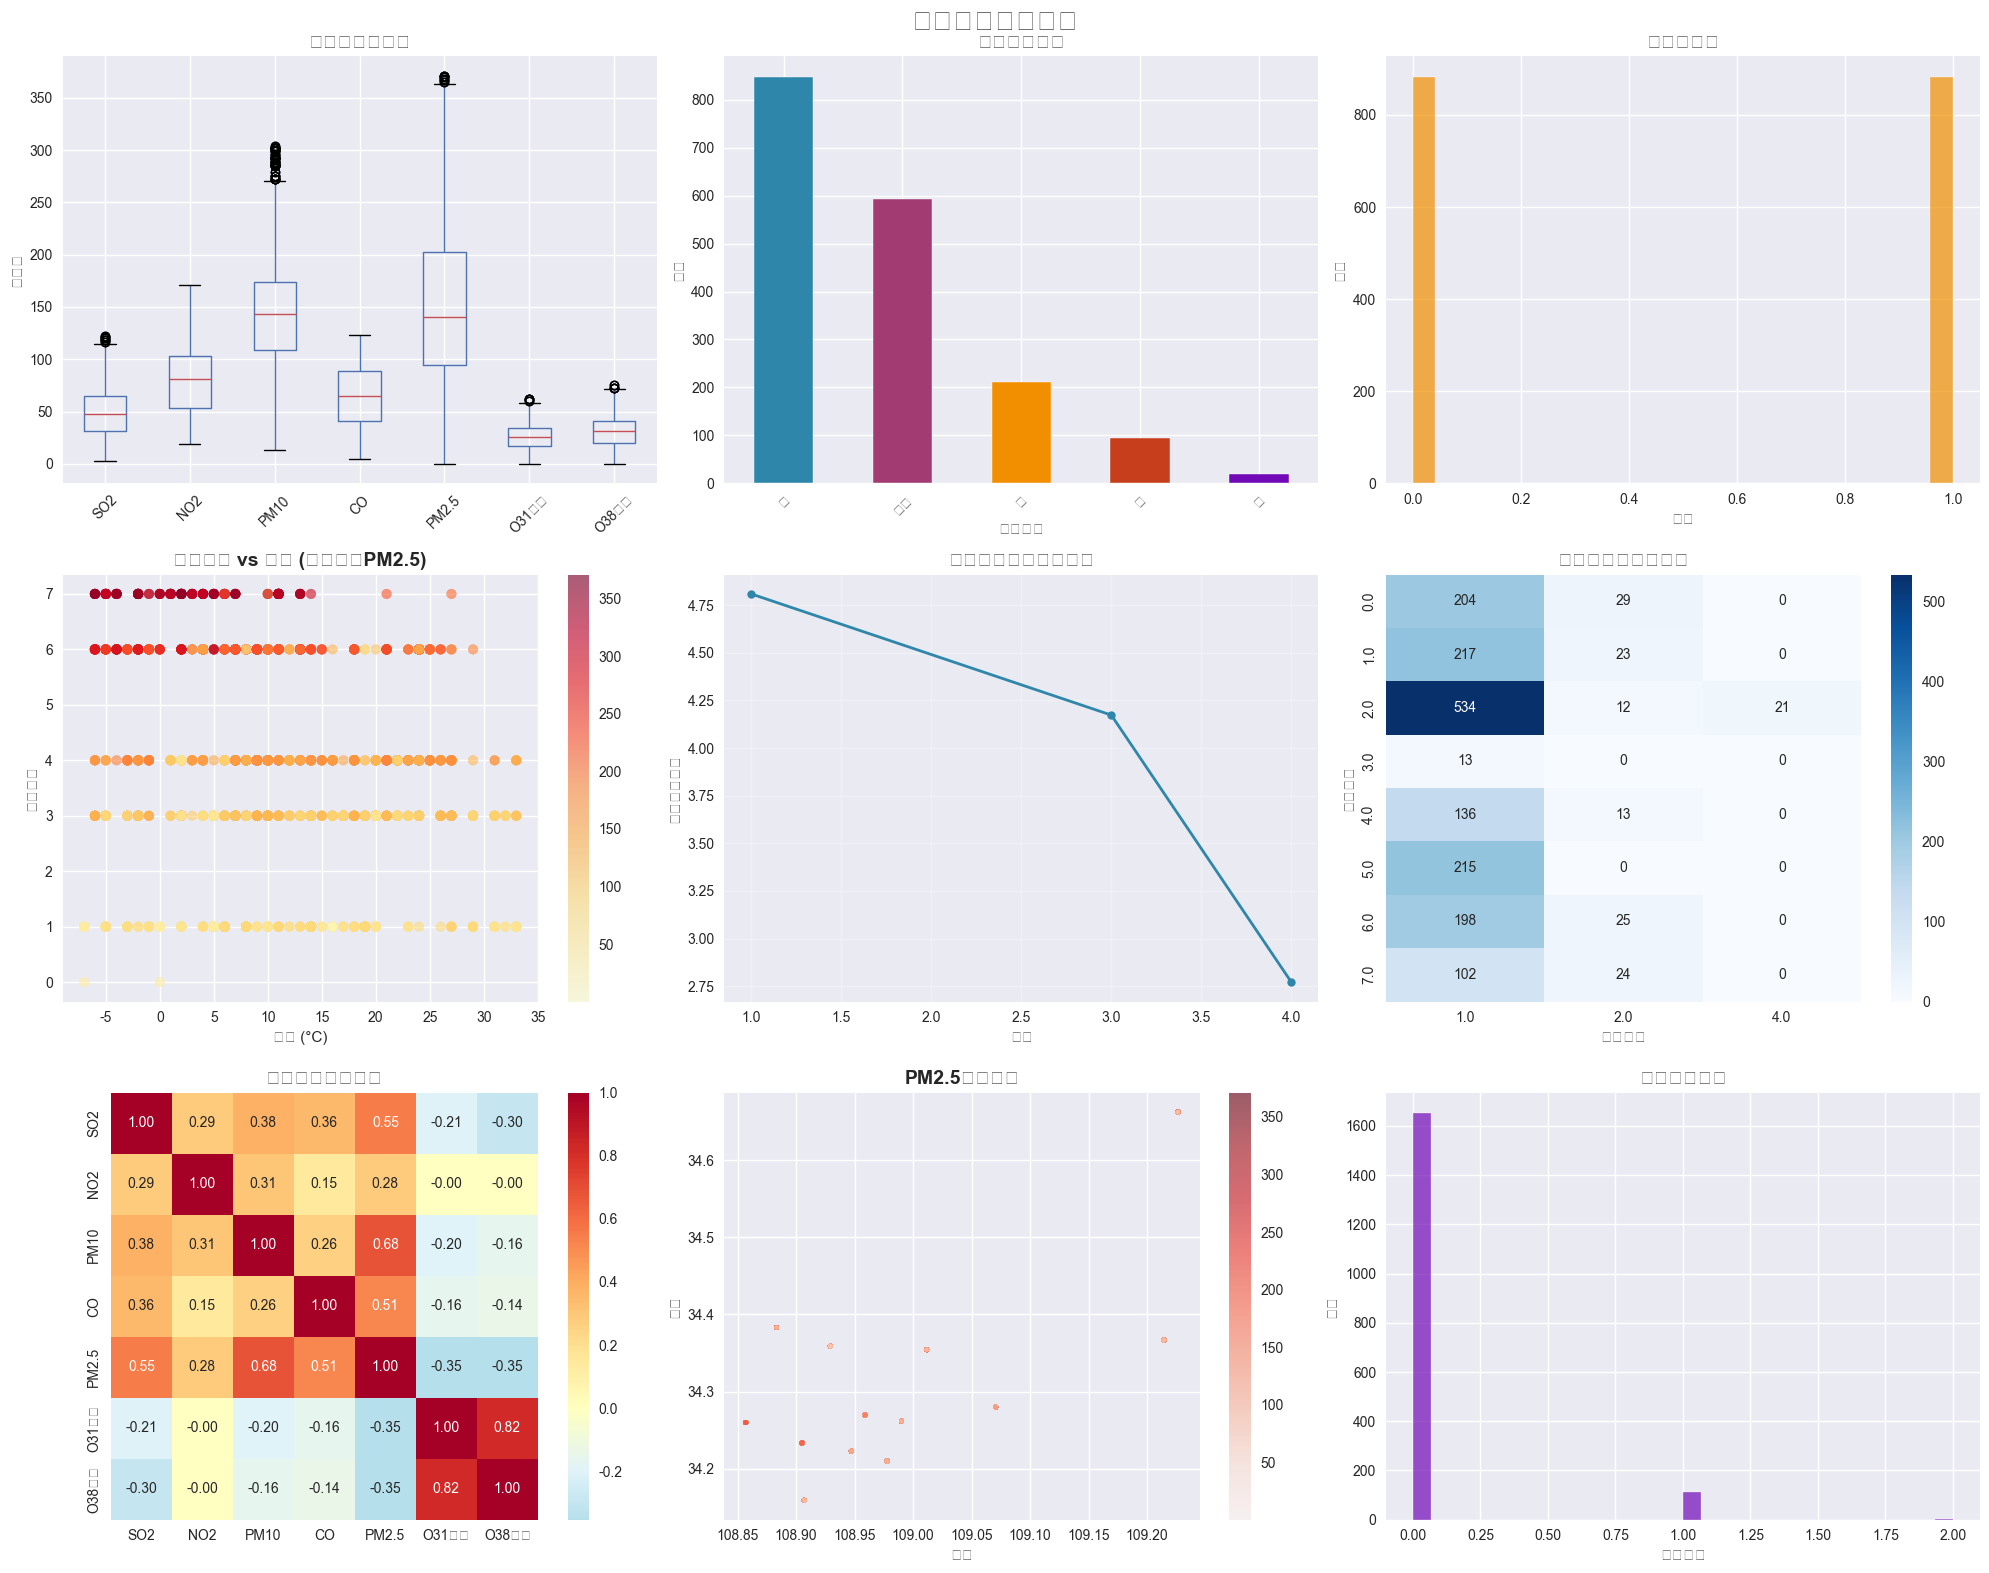

生成特征关系可视化...


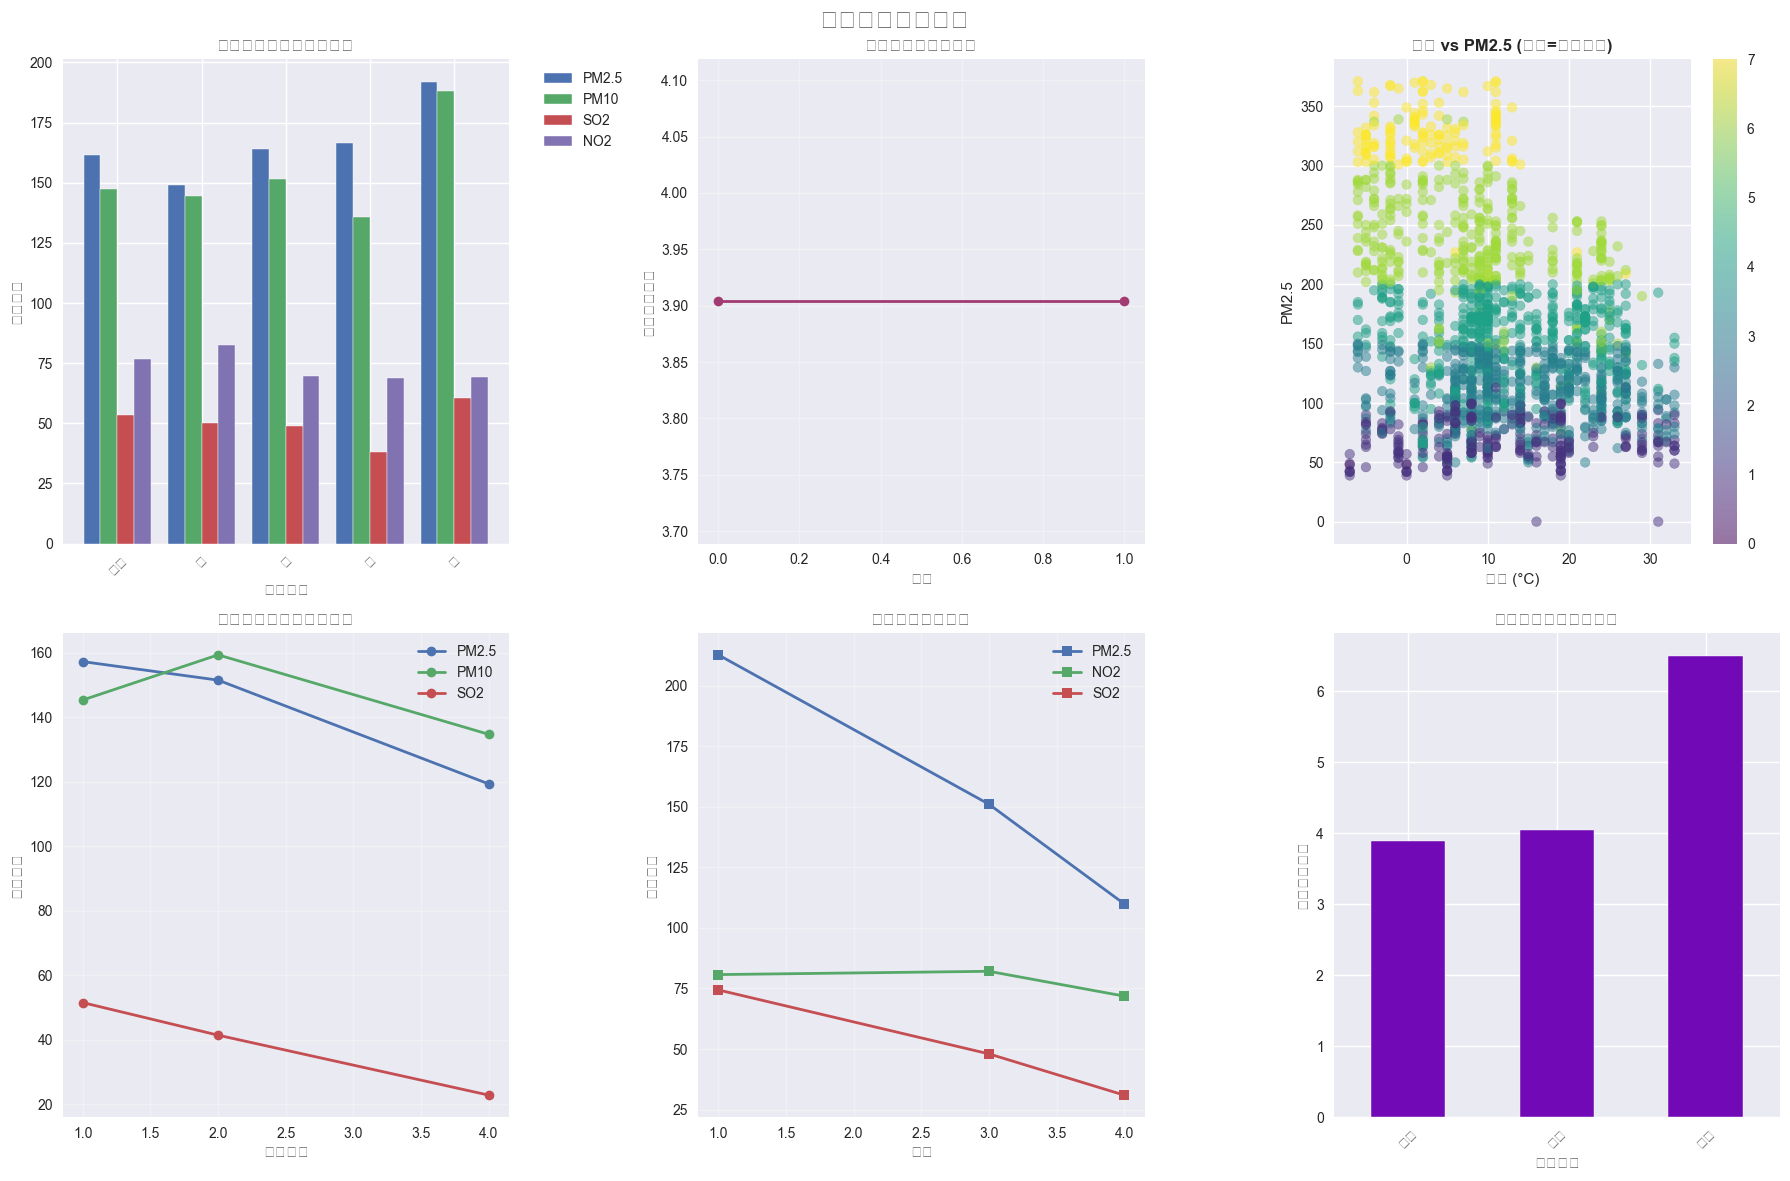

准备训练数据...
污染物预处理...
原始范围: [0.000, 371.000]
标准化后范围: [-2.000, 2.477]
数据准备完成:
  X shape: (1766, 23), 范围: [-5.000, 4.790]
  天气类别数: 5
  风力范围: 1-4
  降水范围: 0.000-2.000
  污染物scaled范围: -2.000-2.477
训练集大小: 1412, 测试集大小: 354
训练模型...
构建模型: 输入形状 (23,)
开始训练...
Epoch 1/30
67/71 [===========================>..] - ETA: 0s - loss: nan - weather_output_loss: nan - wind_output_loss: nan - rain_output_loss: nan - pollutants_output_loss: nan - weather_output_accuracy: 0.2715 - wind_output_accuracy: 0.1427 - rain_output_mae: nan - pollutants_output_mae: nanEpoch 0: 检测到NaN损失，停止训练
Epoch 0: loss=nan, val_loss=nan
71/71 [==============================] - 2s 15ms/step - loss: nan - weather_output_loss: nan - wind_output_loss: nan - rain_output_loss: nan - pollutants_output_loss: nan - weather_output_accuracy: 0.2764 - wind_output_accuracy: 0.1355 - rain_output_mae: nan - pollutants_output_mae: nan - val_loss: nan - val_weather_output_loss: nan - val_wind_output_loss: nan - val_rain_output_loss: nan - val_pollutant

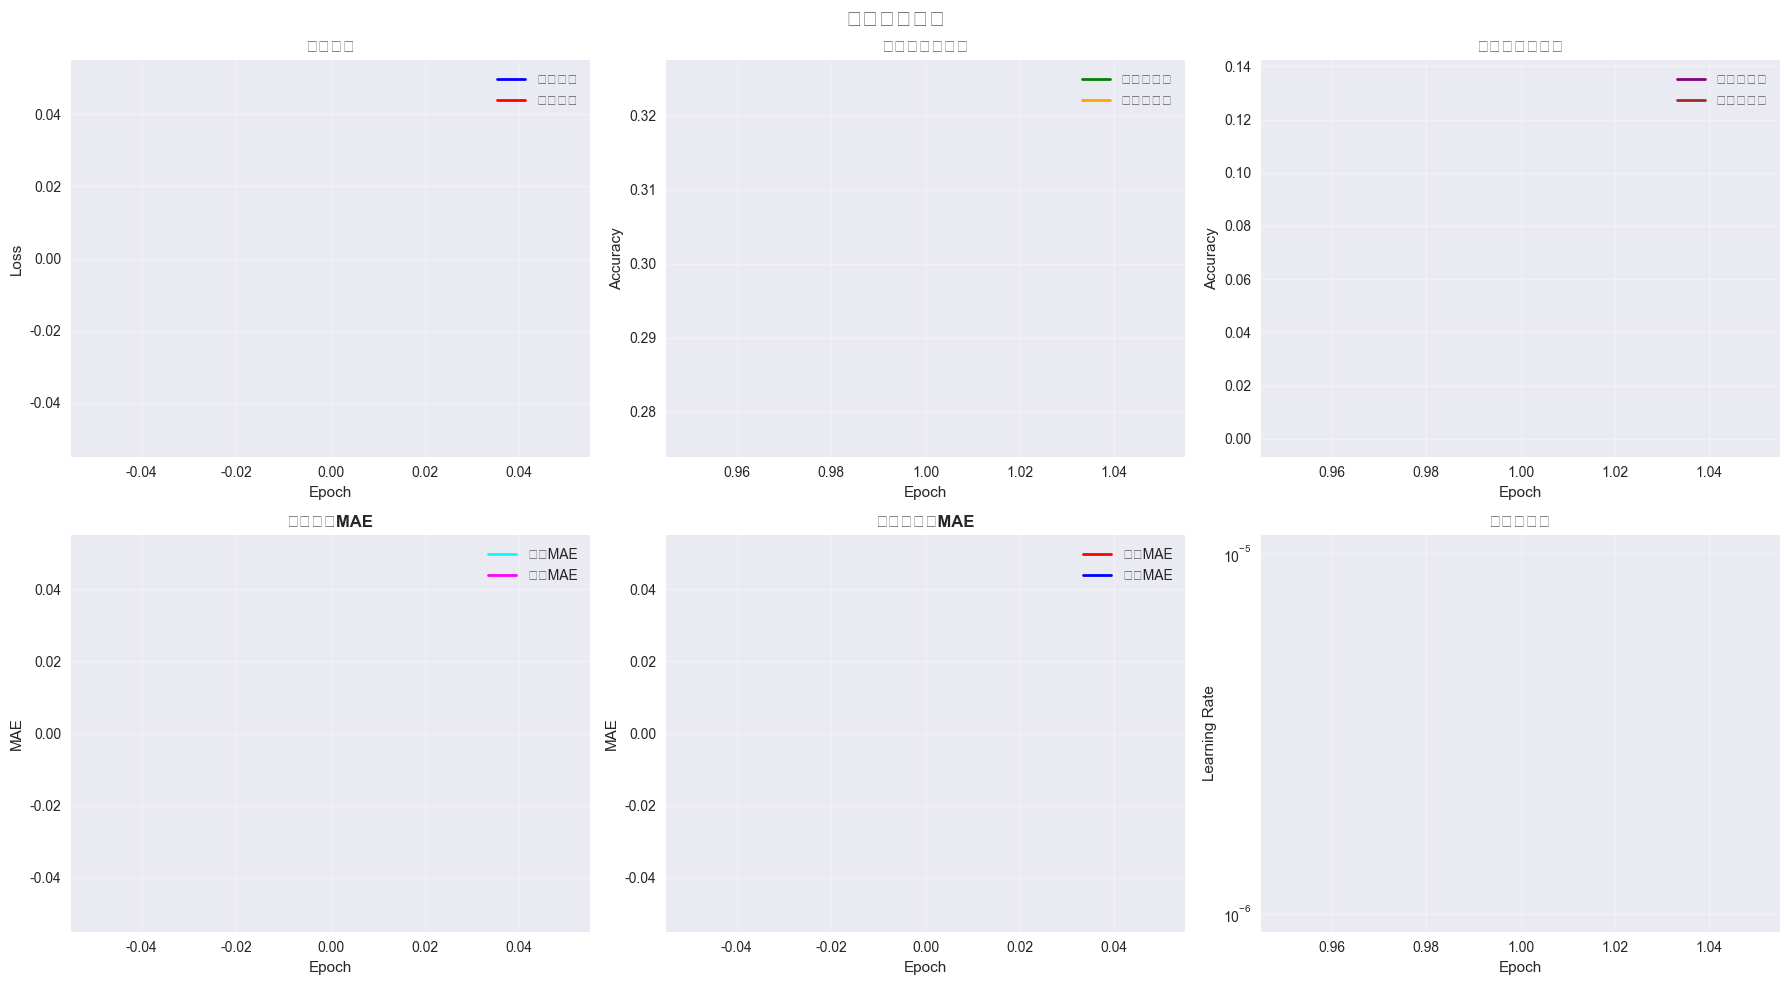

评估模型...
天气预测出现NaN，使用默认值
风力预测出现NaN，使用默认值
清理降水预测中的异常值...
清理污染物预测中的异常值...
生成评估结果可视化...
天气预测出现NaN，使用默认值
风力预测出现NaN，使用默认值
清理降水预测中的异常值...
清理污染物预测中的异常值...
天气预测出现NaN，使用默认值
风力预测出现NaN，使用默认值
清理降水预测中的异常值...
清理污染物预测中的异常值...


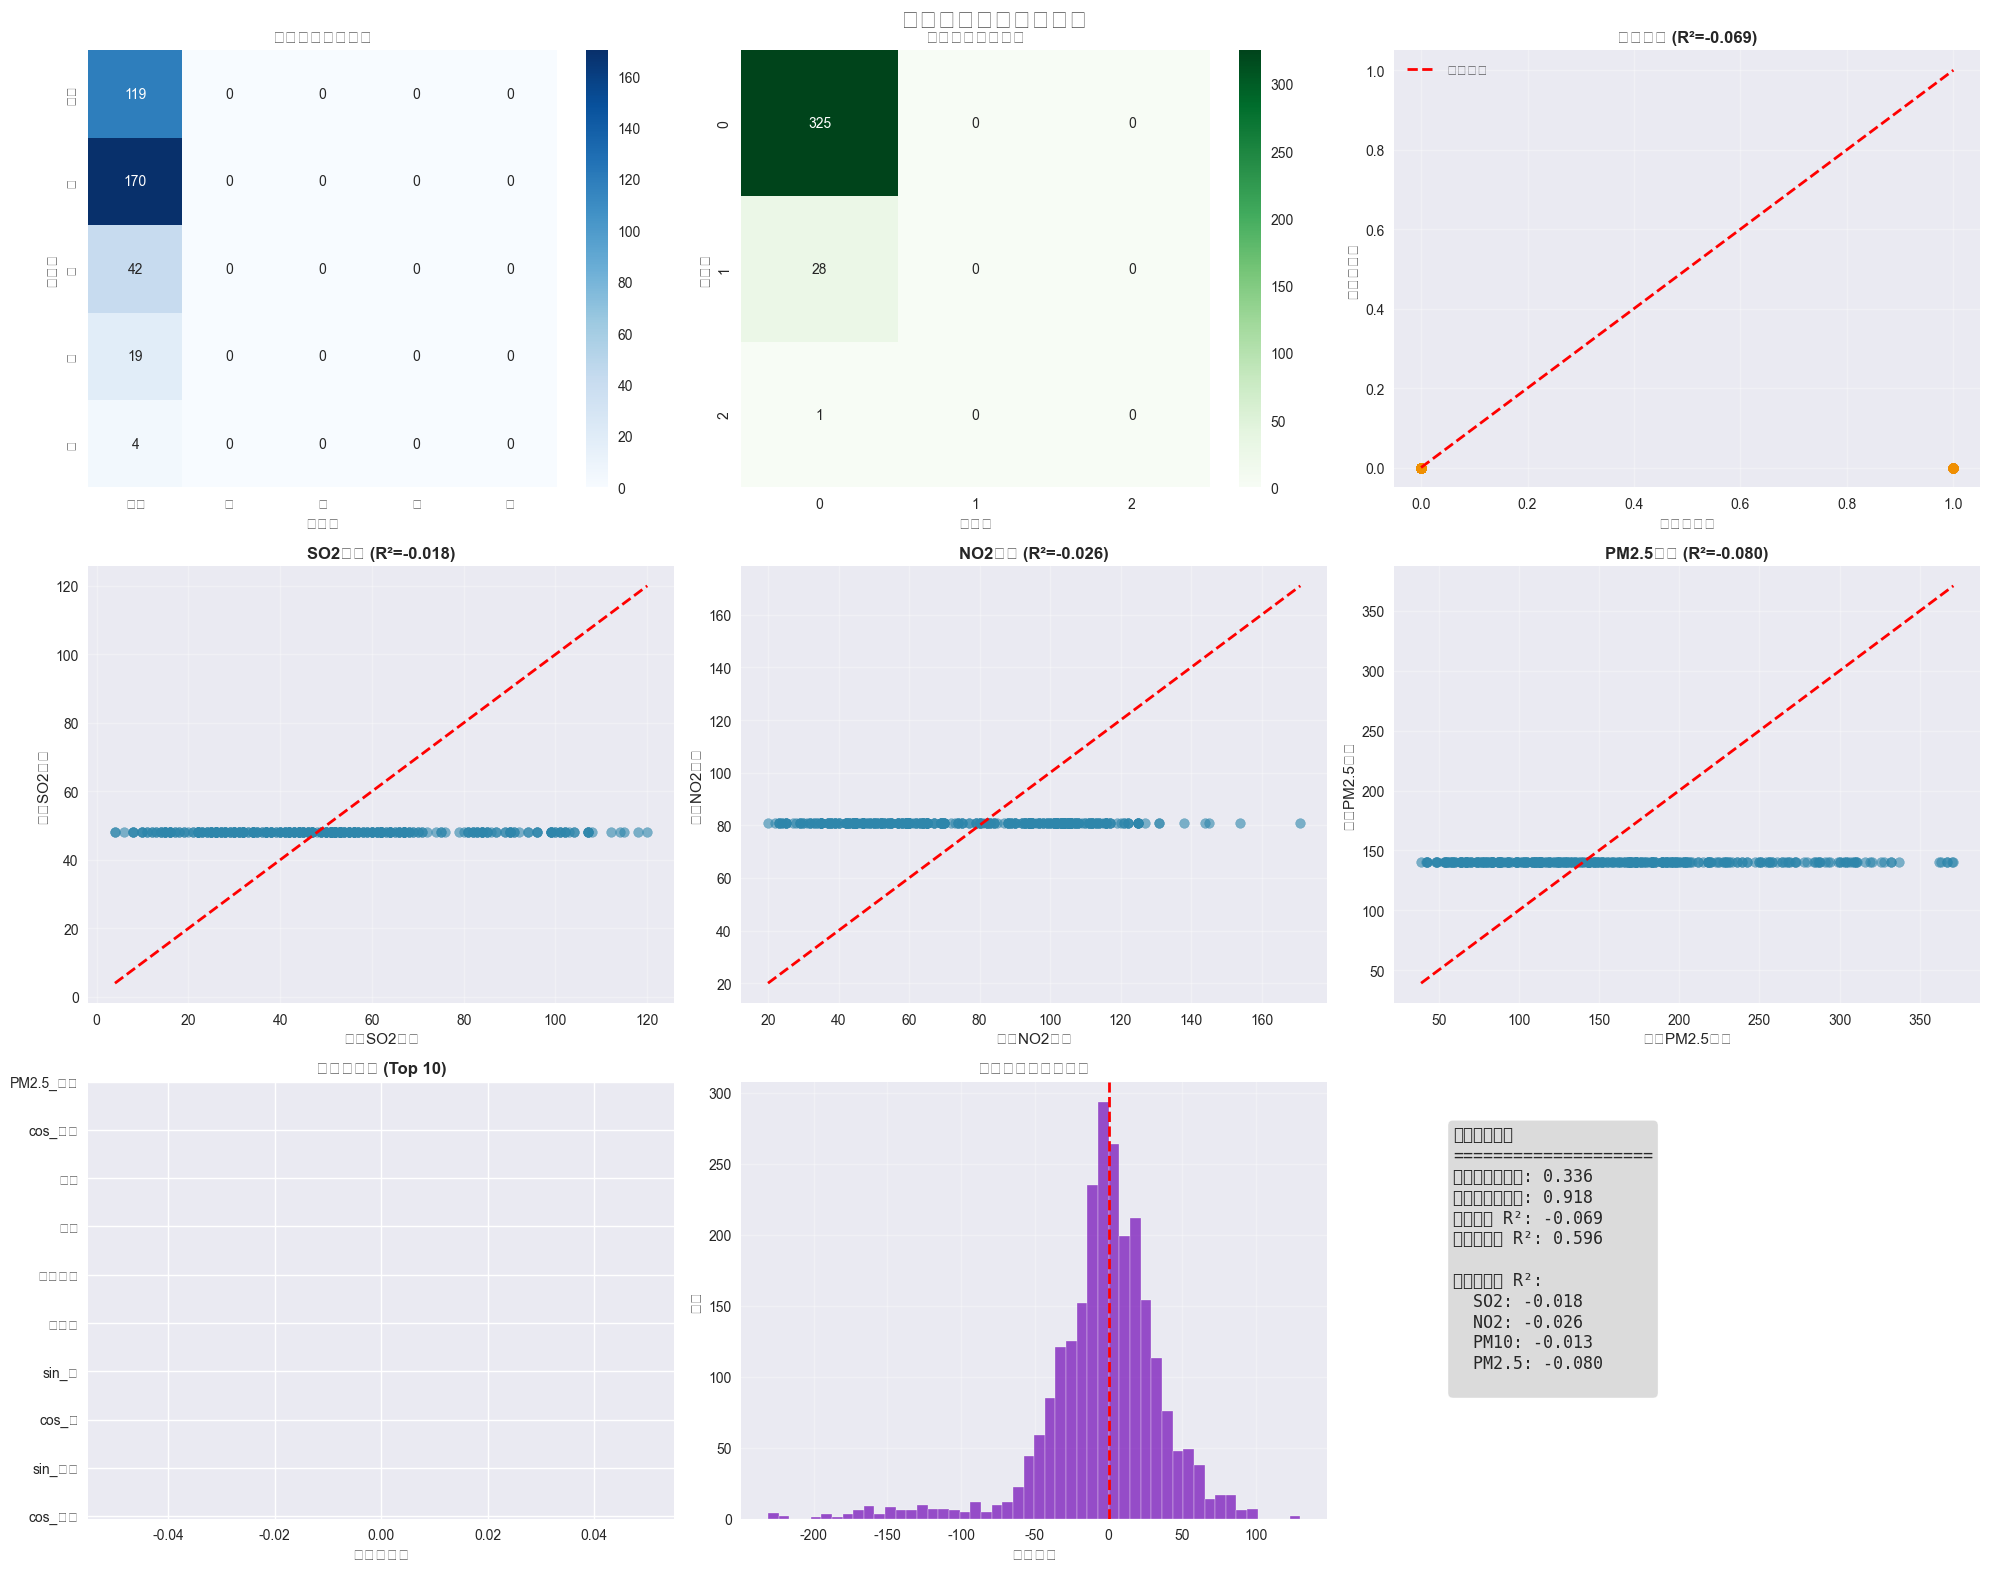

生成综合报告...
综合报告已保存至: comprehensive_report.html

评估结果:
weather_accuracy: 0.3362
wind_accuracy: 0.9181
rain_mae: 0.06497175246477127
rain_r2: -0.0695
pollutants_mae: 27.79983901977539
pollutants_r2: 0.5957
SO2_mae: 20.40113067626953
SO2_r2: -0.0179
NO2_mae: 26.776836395263672
NO2_r2: -0.0255
PM10_mae: 38.88983154296875
PM10_r2: -0.0125
CO_mae: 23.305084228515625
CO_r2: -0.0025
O31小时_mae: 9.192090034484863
O31小时_r2: -0.0091
O38小时_mae: 11.920904159545898
O38小时_r2: -0.0056
PM2.5_mae: 64.11299133300781
PM2.5_r2: -0.0800

训练完成！所有可视化图表和报告已生成。
生成的文件:
- data_overview.png: 数据概览
- feature_relationships.png: 特征关系分析
- training_history.png: 训练历史
- evaluation_results.png: 评估结果
- comprehensive_report.html: 综合报告


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report, r2_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import joblib
import os
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
warnings.filterwarnings('ignore')
import plotly.graph_objects as go

# 设置全局模板以支持中文
plt_template = go.layout.Template()

plt_template.layout.font.family = "SimHei"
plt_template.layout.title.font.family = "SimHei"
plt_template.layout.xaxis.title.font.family = "SimHei"
plt_template.layout.yaxis.title.font.family = "SimHei"
plt_template.layout.legend.font.family = "SimHei"

# 应用模板为全局默认
go.Figure().update_layout(template=plt_template)
# 设置中文字

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)

# 关键修复：设置TensorFlow数值稳定性
tf.keras.backend.set_floatx('float32')
physical_devices = tf.config.list_physical_devices('GPU')


class EnhancedEnvironmentalPredictor:
    """增强的环境预测器 - 包含完整的可视化功能"""
    
    def __init__(self):
        # 使用更稳定的标准化器
        self.scaler_features = RobustScaler()
        self.scaler_pollutants = RobustScaler()
        self.weather_encoder = None
        self.is_fitted = False
        self.use_sequences = False
        self.sequence_length = None
        self.feature_names = None
        self.history = None
        self.evaluation_results = None
        
        # 关键：添加数据范围限制
        self.feature_clip_range = (-5, 5)
        self.pollutant_clip_range = (-5, 5)
        
        # 可视化配置
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'success': '#C73E1D',
            'info': '#7209B7',
            'warning': '#F4A261',
            'danger': '#E63946'
        }

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据 - 更严格的数据清理"""
        columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                  '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                  '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        data = pd.read_csv(file_path, usecols=columns)
        print(f"原始数据: {data.shape}")
        
        # 关键修复1：更激进的离群值清理
        numeric_cols = ['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5']
        for col in numeric_cols:
            # 使用IQR方法移除离群值
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            print(f"{col}: IQR范围 [{lower_bound:.3f}, {upper_bound:.3f}]")
            data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
        
        print(f"移除离群值后: {data.shape}")
        
        # 强制转换数值类型并处理无效值
        numeric_columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                          '污染程度', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                          '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        for col in numeric_columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
            # 关键：用中位数填充NaN而不是删除
            if data[col].isna().sum() > 0:
                median_val = data[col].median()
                data[col].fillna(median_val, inplace=True)
                print(f"{col}: 用中位数 {median_val:.3f} 填充了 {data[col].isna().sum()} 个NaN值")
        
        # 日期处理
        data['日期'] = pd.to_datetime(data['日期'])
        data['年'] = data['日期'].dt.year
        data['月'] = data['日期'].dt.month
        data['日'] = data['日期'].dt.day
        data['星期'] = data['日期'].dt.dayofweek
        
        # 天气标签处理
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        data['天气类别'] = data[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 循环时间特征 - 使用更稳定的范围
        data['sin_月'] = np.sin(2 * np.pi * data['月'] / 12)
        data['cos_月'] = np.cos(2 * np.pi * data['月'] / 12)
        data['sin_时间'] = np.sin(2 * np.pi * data['时间段'] / 24)
        data['cos_时间'] = np.cos(2 * np.pi * data['时间段'] / 24)
        data['sin_星期'] = np.sin(2 * np.pi * data['星期'] / 7)
        data['cos_星期'] = np.cos(2 * np.pi * data['星期'] / 7)
        
        # 关键修复2：更安全的污染物特征工程
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']
        
        # 确保所有值为正数，避免log问题
        for col in pollutant_cols:
            data[col] = np.maximum(data[col], 0.1)  # 最小值设为0.1
        
        # 使用更稳定的比例计算
        data['污染物总和'] = data[pollutant_cols].sum(axis=1)
        data['污染物总和'] = np.maximum(data['污染物总和'], 1.0)  # 避免除零
        
        for col in pollutant_cols:
            data[f'{col}_比例'] = data[col] / data['污染物总和']
            # 确保比例在合理范围内
            data[f'{col}_比例'] = np.clip(data[f'{col}_比例'], 0.001, 0.999)
        
        # 添加对数特征（更安全）
        for col in pollutant_cols:
            data[f'{col}_log'] = np.log1p(data[col])  # log1p更安全
        
        # 最终数据清理
        data = data.replace([np.inf, -np.inf], np.nan)
        data = data.dropna()
        
        print(f"最终数据: {data.shape}")
        self.raw_data = data.copy()  # 保存原始数据用于可视化
        return data

    def visualize_data_overview(self, data, save_path='data_overview.png'):
        """数据概览可视化"""
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        fig.suptitle('环境数据全面概览', fontsize=20, fontweight='bold')
        
        # 1. 污染物分布
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5', 'O31小时', 'O38小时']
        ax = axes[0, 0]
        data[pollutant_cols].boxplot(ax=ax)
        ax.set_title('污染物浓度分布', fontsize=14, fontweight='bold')
        ax.set_ylabel('浓度值')
        ax.tick_params(axis='x', rotation=45)
        
        # 2. 天气类别分布
        ax = axes[0, 1]
        weather_counts = data['天气类别'].value_counts()
        colors = [self.colors['primary'], self.colors['secondary'], self.colors['accent'], 
                 self.colors['success'], self.colors['info'], self.colors['warning']]
        weather_counts.plot(kind='bar', ax=ax, color=colors[:len(weather_counts)])
        ax.set_title('天气类别分布', fontsize=14, fontweight='bold')
        ax.set_ylabel('频次')
        ax.tick_params(axis='x', rotation=45)
        
        # 3. 时间分布
        ax = axes[0, 2]
        data['时间段'].hist(bins=24, ax=ax, color=self.colors['accent'], alpha=0.7)
        ax.set_title('时间段分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('小时')
        ax.set_ylabel('频次')
        
        # 4. 污染程度与气温关系
        ax = axes[1, 0]
        scatter = ax.scatter(data['气温'], data['污染程度'], 
                           c=data['PM2.5'], cmap='YlOrRd', alpha=0.6)
        ax.set_title('污染程度 vs 气温 (颜色表示PM2.5)', fontsize=14, fontweight='bold')
        ax.set_xlabel('气温 (°C)')
        ax.set_ylabel('污染程度')
        plt.colorbar(scatter, ax=ax)
        
        # 5. 月度趋势
        ax = axes[1, 1]
        monthly_pollution = data.groupby('月')['污染程度'].mean()
        monthly_pollution.plot(kind='line', ax=ax, marker='o', 
                              color=self.colors['primary'], linewidth=2, markersize=6)
        ax.set_title('月度平均污染程度趋势', fontsize=14, fontweight='bold')
        ax.set_xlabel('月份')
        ax.set_ylabel('平均污染程度')
        ax.grid(True, alpha=0.3)
        
        # 6. 风力风向分布
        ax = axes[1, 2]
        wind_data = data.groupby(['风向编码', '风力编码']).size().unstack(fill_value=0)
        sns.heatmap(wind_data, ax=ax, cmap='Blues', annot=True, fmt='d')
        ax.set_title('风力风向分布热力图', fontsize=14, fontweight='bold')
        ax.set_xlabel('风力编码')
        ax.set_ylabel('风向编码')
        
        # 7. 污染物相关性
        ax = axes[2, 0]
        pollutant_corr = data[pollutant_cols].corr()
        sns.heatmap(pollutant_corr, ax=ax, annot=True, cmap='RdYlBu_r', 
                   center=0, square=True, fmt='.2f')
        ax.set_title('污染物相关性矩阵', fontsize=14, fontweight='bold')
        
        # 8. 地理分布
        ax = axes[2, 1]
        scatter = ax.scatter(data['经度'], data['纬度'], 
                           c=data['PM2.5'], cmap='Reds', alpha=0.6, s=10)
        ax.set_title('PM2.5地理分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('经度')
        ax.set_ylabel('纬度')
        plt.colorbar(scatter, ax=ax)
        
        # 9. 降水强度分布
        ax = axes[2, 2]
        data['降水强度'].hist(bins=30, ax=ax, color=self.colors['info'], alpha=0.7)
        ax.set_title('降水强度分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('降水强度')
        ax.set_ylabel('频次')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def visualize_feature_relationships(self, data, save_path='feature_relationships.png'):
        """特征关系可视化"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('特征关系深度分析', fontsize=18, fontweight='bold')
        
        # 1. 污染物vs天气类别
        ax = axes[0, 0]
        weather_pollution = data.groupby('天气类别')[['PM2.5', 'PM10', 'SO2', 'NO2']].mean()
        weather_pollution.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title('不同天气下的污染物浓度', fontsize=12, fontweight='bold')
        ax.set_ylabel('平均浓度')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # 2. 时间vs污染程度
        ax = axes[0, 1]
        hour_pollution = data.groupby('时间段')['污染程度'].mean()
        hour_pollution.plot(ax=ax, color=self.colors['secondary'], linewidth=2, marker='o')
        ax.set_title('一日内污染程度变化', fontsize=12, fontweight='bold')
        ax.set_xlabel('小时')
        ax.set_ylabel('平均污染程度')
        ax.grid(True, alpha=0.3)
        
        # 3. 气温vs污染物散点图矩阵
        ax = axes[0, 2]
        temp_pm25 = ax.scatter(data['气温'], data['PM2.5'], alpha=0.5, 
                              c=data['污染程度'], cmap='viridis')
        ax.set_title('气温 vs PM2.5 (颜色=污染程度)', fontsize=12, fontweight='bold')
        ax.set_xlabel('气温 (°C)')
        ax.set_ylabel('PM2.5')
        plt.colorbar(temp_pm25, ax=ax)
        
        # 4. 风力对污染的影响
        ax = axes[1, 0]
        wind_pollution = data.groupby('风力编码')[['PM2.5', 'PM10', 'SO2']].mean()
        wind_pollution.plot(ax=ax, marker='o', linewidth=2)
        ax.set_title('风力等级对污染物的影响', fontsize=12, fontweight='bold')
        ax.set_xlabel('风力等级')
        ax.set_ylabel('平均浓度')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # 5. 季节性分析
        ax = axes[1, 1]
        seasonal_data = data.groupby('月')[['PM2.5', 'NO2', 'SO2']].mean()
        seasonal_data.plot(ax=ax, marker='s', linewidth=2)
        ax.set_title('季节性污染物变化', fontsize=12, fontweight='bold')
        ax.set_xlabel('月份')
        ax.set_ylabel('平均浓度')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # 6. 降水vs污染关系
        ax = axes[1, 2]
        # 将降水强度分组
        data['降水等级'] = pd.cut(data['降水强度'], bins=5, labels=['很少', '少', '中等', '多', '很多'])
        rain_pollution = data.groupby('降水等级')['污染程度'].mean().dropna()
        rain_pollution.plot(kind='bar', ax=ax, color=self.colors['info'])
        ax.set_title('降水对污染程度的影响', fontsize=12, fontweight='bold')
        ax.set_ylabel('平均污染程度')
        ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def prepare_data(self, data, use_sequences=False, sequence_length=24):
        """准备训练数据 - 彻底修复版本"""
        self.use_sequences = use_sequences
        self.sequence_length = sequence_length
        
        # 定义特征列 - 使用更稳定的特征组合
        feature_cols = [
            '纬度', '经度', '气温', '污染程度', '时间段',
            'sin_月', 'cos_月', 'sin_时间', 'cos_时间', 'sin_星期', 'cos_星期',
            '风向编码', '风力编码',
            'SO2_log', 'NO2_log', 'PM10_log', 'CO_log', 'PM2.5_log',
            'SO2_比例', 'NO2_比例', 'PM10_比例', 'CO_比例', 'PM2.5_比例'
        ]
        
        if not use_sequences:
            X = data[feature_cols].values.astype(np.float32)
            y_weather = data['天气类别'].values
            y_wind = data['风力编码'].values.astype(np.int32)
            y_rain = data['降水强度'].values.astype(np.float32)
            
            pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5']
            y_pollutants = data[pollutant_cols].values.astype(np.float32)
            
            self.feature_names = feature_cols
        else:
            # 时序数据创建（简化版本）
            X, y_weather, y_wind, y_rain, y_pollutants = self._create_sequences_safe(
                data, feature_cols, sequence_length)
        
        # 关键修复3：数据标准化前的清理
        X = self._clean_array(X, "特征矩阵")
        y_wind = self._clean_array(y_wind, "风力")
        y_rain = self._clean_array(y_rain, "降水")
        y_pollutants = self._clean_array(y_pollutants, "污染物")
        
        # 标准化特征
        if use_sequences:
            original_shape = X.shape
            X_flat = X.reshape(-1, X.shape[-1])
            X_scaled_flat = self.scaler_features.fit_transform(X_flat)
            X_scaled = X_scaled_flat.reshape(original_shape)
        else:
            X_scaled = self.scaler_features.fit_transform(X)
        
        # 关键修复4：严格限制数值范围
        X_scaled = np.clip(X_scaled, *self.feature_clip_range)
        
        # 关键修复5：污染物预处理 - 使用更稳定的方法
        print("污染物预处理...")
        print(f"原始范围: [{y_pollutants.min():.3f}, {y_pollutants.max():.3f}]")
        
        # 直接使用RobustScaler，不做对数变换
        y_pollutants_scaled = self.scaler_pollutants.fit_transform(y_pollutants)
        y_pollutants_scaled = np.clip(y_pollutants_scaled, *self.pollutant_clip_range)
        
        print(f"标准化后范围: [{y_pollutants_scaled.min():.3f}, {y_pollutants_scaled.max():.3f}]")
        
        # 编码天气类别
        self.weather_encoder = LabelEncoder()
        y_weather_encoded = self.weather_encoder.fit_transform(y_weather)
        
        # 确保风力和降水数据的合理性
        y_wind = np.clip(y_wind.astype(int), 0, 12)  # 风力等级0-12
        y_rain = np.clip(y_rain, 0, 50)  # 降水量合理上限
        
        # 最终验证
        print(f"数据准备完成:")
        print(f"  X shape: {X_scaled.shape}, 范围: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
        print(f"  天气类别数: {len(np.unique(y_weather_encoded))}")
        print(f"  风力范围: {y_wind.min()}-{y_wind.max()}")
        print(f"  降水范围: {y_rain.min():.3f}-{y_rain.max():.3f}")
        print(f"  污染物scaled范围: {y_pollutants_scaled.min():.3f}-{y_pollutants_scaled.max():.3f}")
        
        return X_scaled, y_weather_encoded, y_wind, y_rain, y_pollutants_scaled

    def _clean_array(self, arr, name):
        """清理数组中的异常值"""
        if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
            print(f"清理{name}中的异常值...")
            arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)
        return arr.astype(np.float32)

    def _create_sequences_safe(self, data, feature_cols, sequence_length):
        """创建安全的时序数据"""
        # 简化的时序数据创建，避免复杂的分组操作
        print("创建时序数据...")
        
        # 按日期排序
        data_sorted = data.sort_values(['日期', '时间段'])
        
        sequences_X = []
        sequences_y_weather = []
        sequences_y_wind = []
        sequences_y_rain = []
        sequences_y_pollutants = []
        
        for i in range(len(data_sorted) - sequence_length):
            seq_X = data_sorted[feature_cols].iloc[i:i+sequence_length].values
            target_row = data_sorted.iloc[i+sequence_length]
            
            # 检查序列完整性
            if not np.any(np.isnan(seq_X)) and not np.any(np.isinf(seq_X)):
                sequences_X.append(seq_X)
                sequences_y_weather.append(target_row['天气类别'])
                sequences_y_wind.append(target_row['风力编码'])
                sequences_y_rain.append(target_row['降水强度'])
                
                pollutant_vals = target_row[['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5']].values
                sequences_y_pollutants.append(pollutant_vals)
        
        return (np.array(sequences_X, dtype=np.float32),
                np.array(sequences_y_weather),
                np.array(sequences_y_wind, dtype=np.float32),
                np.array(sequences_y_rain, dtype=np.float32),
                np.array(sequences_y_pollutants, dtype=np.float32))

    def build_stable_model(self, input_shape, num_weather_classes, num_wind_classes):
        """构建数值稳定的模型"""
        # 关键修复6：使用更保守的模型架构
        if self.use_sequences:
            inputs = Input(shape=input_shape, name='input')
            
            # 简单的LSTM，避免过度复杂
            x = LSTM(16, dropout=0.1, recurrent_dropout=0.1,
                    kernel_initializer='orthogonal',  # 更稳定的初始化
                    recurrent_initializer='orthogonal')(inputs)
            x = BatchNormalization()(x)
            
        else:
            inputs = Input(shape=input_shape, name='input')
            
            # 简单的全连接网络
            x = Dense(32, activation='relu', kernel_initializer='he_normal')(inputs)
            x = BatchNormalization()(x)
            x = Dropout(0.2)(x)
            
            x = Dense(16, activation='relu', kernel_initializer='he_normal')(x)
            x = BatchNormalization()(x)
        
        # 输出层 - 使用数值稳定的配置
        weather_output = Dense(num_weather_classes, activation='softmax',
                              kernel_initializer='glorot_uniform',
                              name='weather_output')(x)
        
        wind_output = Dense(num_wind_classes, activation='softmax',
                           kernel_initializer='glorot_uniform',
                           name='wind_output')(x)
        
        rain_output = Dense(1, activation='softplus',  # softplus更稳定than relu
                           kernel_initializer='glorot_uniform',
                           name='rain_output')(x)
        
        pollutants_output = Dense(7, activation='linear',
                                 kernel_initializer='glorot_uniform',
                                 name='pollutants_output')(x)
        
        model = Model(inputs=inputs, 
                     outputs=[weather_output, wind_output, rain_output, pollutants_output])
        
        # 关键修复7：极其保守的训练配置
        losses = {
            'weather_output': 'sparse_categorical_crossentropy',
            'wind_output': 'sparse_categorical_crossentropy', 
            'rain_output': 'mse',
            'pollutants_output': 'mse'
        }
        
        # 关键：进一步降低权重，特别是污染物
        loss_weights = {
            'weather_output': 1.0,
            'wind_output': 1.0,
            'rain_output': 0.01,      # 大幅降低
            'pollutants_output': 0.001  # 极低权重
        }
        
        # 使用极其保守的优化器设置
        optimizer = Adam(
            learning_rate=1e-5,    # 极小的学习率
            clipnorm=0.1,         # 严格的梯度裁剪
            clipvalue=0.1         # 梯度值裁剪
        )
        
        model.compile(
            optimizer=optimizer,
            loss=losses,
            loss_weights=loss_weights,
            metrics={
                'weather_output': ['accuracy'],
                'wind_output': ['accuracy'],
                'rain_output': ['mae'],
                'pollutants_output': ['mae']
            }
        )
        
        return model

    def train(self, X, y_weather, y_wind, y_rain, y_pollutants, 
              validation_split=0.2, epochs=50, batch_size=16):
        """训练模型 - 稳定版本"""
        
        # 构建模型
        if self.use_sequences:
            input_shape = (X.shape[1], X.shape[2])
        else:
            input_shape = (X.shape[1],)
        
        num_weather_classes = len(np.unique(y_weather))
        num_wind_classes = len(np.unique(y_wind))
        
        print(f"构建模型: 输入形状 {input_shape}")
        self.model = self.build_stable_model(input_shape, num_weather_classes, num_wind_classes)
        
        # 准备目标数据
        targets = {
            'weather_output': y_weather,
            'wind_output': y_wind,
            'rain_output': y_rain,
            'pollutants_output': y_pollutants
        }
        
        # 数值稳定性回调
        class StabilityCallback(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                # 检查损失
                loss = logs.get('loss', 0)
                val_loss = logs.get('val_loss', 0)
                
                if np.isnan(loss) or np.isnan(val_loss):
                    print(f"Epoch {epoch}: 检测到NaN损失，停止训练")
                    self.model.stop_training = True
                
                if epoch % 10 == 0:
                    print(f"Epoch {epoch}: loss={loss:.6f}, val_loss={val_loss:.6f}")
        
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=15,
                restore_best_weights=True,
                min_delta=1e-6
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=8,
                min_lr=1e-8,
                min_delta=1e-6
            ),
            StabilityCallback()
        ]
        
        print("开始训练...")
        history = self.model.fit(
            X, targets,
            validation_split=validation_split,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        self.is_fitted = True
        self.history = history
        return history

    def predict(self, X):
        """预测 - 稳定版本"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        X = self._clean_array(X, "预测输入")
        predictions = self.model.predict(X, verbose=0)
        
        result = {}
        
        # 天气预测
        weather_probs = predictions[0]
        if np.any(np.isnan(weather_probs)):
            print("天气预测出现NaN，使用默认值")
            weather_pred = np.zeros(len(weather_probs), dtype=int)
        else:
            weather_pred = np.argmax(weather_probs, axis=1)
        result['weather'] = self.weather_encoder.inverse_transform(weather_pred)
        result['weather_probs'] = weather_probs
        
        # 风力预测
        wind_probs = predictions[1]
        if np.any(np.isnan(wind_probs)):
            print("风力预测出现NaN，使用默认值")
            wind_pred = np.ones(len(wind_probs), dtype=int)
        else:
            wind_pred = np.argmax(wind_probs, axis=1)
        result['wind'] = wind_pred
        result['wind_probs'] = wind_probs
        
        # 降水预测
        rain_pred = predictions[2].flatten()
        rain_pred = self._clean_array(rain_pred, "降水预测")
        result['rain'] = rain_pred
        
        # 污染物预测
        pollutants_pred_scaled = predictions[3]
        pollutants_pred_scaled = self._clean_array(pollutants_pred_scaled, "污染物预测")
        
        # 反标准化
        try:
            pollutants_pred = self.scaler_pollutants.inverse_transform(pollutants_pred_scaled)
            pollutants_pred = np.maximum(pollutants_pred, 0)  # 确保非负
        except:
            print("污染物反标准化失败，使用原始预测")
            pollutants_pred = np.abs(pollutants_pred_scaled)
        
        result['pollutants'] = pollutants_pred
        
        return result

    def evaluate(self, X_test, y_test_dict):
        """评估模型性能"""
        predictions = self.predict(X_test)
        results = {}
        
        # 天气准确率
        try:
            weather_true = self.weather_encoder.inverse_transform(y_test_dict['weather_output'])
            results['weather_accuracy'] = accuracy_score(weather_true, predictions['weather'])
            results['weather_report'] = classification_report(weather_true, predictions['weather'], output_dict=True)
        except:
            results['weather_accuracy'] = 0.0
            results['weather_report'] = {}
        
        # 风力准确率
        try:
            results['wind_accuracy'] = accuracy_score(y_test_dict['wind_output'], predictions['wind'])
            results['wind_report'] = classification_report(y_test_dict['wind_output'], predictions['wind'], output_dict=True)
        except:
            results['wind_accuracy'] = 0.0
            results['wind_report'] = {}
        
        # 降水MAE和R2
        try:
            rain_mae = mean_absolute_error(y_test_dict['rain_output'], predictions['rain'])
            rain_r2 = r2_score(y_test_dict['rain_output'], predictions['rain'])
            results['rain_mae'] = rain_mae
            results['rain_r2'] = rain_r2
        except:
            results['rain_mae'] = np.inf
            results['rain_r2'] = -np.inf
        
        # 污染物MAE和R2
        try:
            # 使用反标准化后的数据比较
            pollutants_true = self.scaler_pollutants.inverse_transform(y_test_dict['pollutants_output'])
            pollutants_mae = mean_absolute_error(pollutants_true.flatten(), predictions['pollutants'].flatten())
            pollutants_r2 = r2_score(pollutants_true.flatten(), predictions['pollutants'].flatten())
            results['pollutants_mae'] = pollutants_mae
            results['pollutants_r2'] = pollutants_r2
            
            # 每个污染物的单独评估
            pollutant_names = ['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5']
            for i, name in enumerate(pollutant_names):
                mae = mean_absolute_error(pollutants_true[:, i], predictions['pollutants'][:, i])
                r2 = r2_score(pollutants_true[:, i], predictions['pollutants'][:, i])
                results[f'{name}_mae'] = mae
                results[f'{name}_r2'] = r2
                
        except Exception as e:
            print(f"污染物评估出错: {e}")
            results['pollutants_mae'] = np.inf
            results['pollutants_r2'] = -np.inf
        
        self.evaluation_results = results
        return results

    def visualize_training_history(self, save_path='training_history.png'):
        """可视化训练历史"""
        if self.history is None:
            print("没有训练历史可供可视化")
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('模型训练历史', fontsize=16, fontweight='bold')
        
        history = self.history.history
        epochs = range(1, len(history['loss']) + 1)
        
        # 1. 总损失
        ax = axes[0, 0]
        ax.plot(epochs, history['loss'], 'b-', label='训练损失', linewidth=2)
        ax.plot(epochs, history['val_loss'], 'r-', label='验证损失', linewidth=2)
        ax.set_title('总体损失', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 2. 天气预测准确率
        ax = axes[0, 1]
        ax.plot(epochs, history['weather_output_accuracy'], 'g-', label='训练准确率', linewidth=2)
        ax.plot(epochs, history['val_weather_output_accuracy'], 'orange', label='验证准确率', linewidth=2)
        ax.set_title('天气预测准确率', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 3. 风力预测准确率
        ax = axes[0, 2]
        ax.plot(epochs, history['wind_output_accuracy'], 'purple', label='训练准确率', linewidth=2)
        ax.plot(epochs, history['val_wind_output_accuracy'], 'brown', label='验证准确率', linewidth=2)
        ax.set_title('风力预测准确率', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 4. 降水预测MAE
        ax = axes[1, 0]
        ax.plot(epochs, history['rain_output_mae'], 'cyan', label='训练MAE', linewidth=2)
        ax.plot(epochs, history['val_rain_output_mae'], 'magenta', label='验证MAE', linewidth=2)
        ax.set_title('降水预测MAE', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MAE')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 5. 污染物预测MAE
        ax = axes[1, 1]
        ax.plot(epochs, history['pollutants_output_mae'], 'red', label='训练MAE', linewidth=2)
        ax.plot(epochs, history['val_pollutants_output_mae'], 'blue', label='验证MAE', linewidth=2)
        ax.set_title('污染物预测MAE', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MAE')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 6. 学习率变化（如果有）
        ax = axes[1, 2]
        if 'lr' in history:
            ax.plot(epochs, history['lr'], 'black', linewidth=2)
            ax.set_title('学习率变化', fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Learning Rate')
            ax.set_yscale('log')
        else:
            ax.text(0.5, 0.5, '学习率信息不可用', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('学习率变化', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def visualize_evaluation_results(self, X_test, y_test_dict, save_path='evaluation_results.png'):
        """可视化评估结果"""
        if self.evaluation_results is None:
            print("请先运行evaluate方法")
            return
        
        predictions = self.predict(X_test)
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        fig.suptitle('模型评估结果详细分析', fontsize=18, fontweight='bold')
        
        # 1. 天气预测混淆矩阵
        ax = axes[0, 0]
        weather_true = self.weather_encoder.inverse_transform(y_test_dict['weather_output'])
        weather_pred = predictions['weather']
        weather_cm = confusion_matrix(weather_true, weather_pred)
        
        sns.heatmap(weather_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=np.unique(weather_true), yticklabels=np.unique(weather_true))
        ax.set_title('天气预测混淆矩阵', fontweight='bold')
        ax.set_xlabel('预测值')
        ax.set_ylabel('真实值')
        
        # 2. 风力预测混淆矩阵
        ax = axes[0, 1]
        wind_cm = confusion_matrix(y_test_dict['wind_output'], predictions['wind'])
        sns.heatmap(wind_cm, annot=True, fmt='d', cmap='Greens', ax=ax)
        ax.set_title('风力预测混淆矩阵', fontweight='bold')
        ax.set_xlabel('预测值')
        ax.set_ylabel('真实值')
        
        # 3. 降水预测散点图
        ax = axes[0, 2]
        rain_true = y_test_dict['rain_output']
        rain_pred = predictions['rain']
        ax.scatter(rain_true, rain_pred, alpha=0.6, color=self.colors['accent'])
        
        # 添加完美预测线
        min_val = min(rain_true.min(), rain_pred.min())
        max_val = max(rain_true.max(), rain_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美预测')
        
        ax.set_title(f'降水预测 (R²={self.evaluation_results.get("rain_r2", 0):.3f})', fontweight='bold')
        ax.set_xlabel('真实降水量')
        ax.set_ylabel('预测降水量')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 4-6. 主要污染物预测对比
        pollutant_names = ['SO2', 'NO2', 'PM2.5']
        pollutant_indices = [0, 1, 6]  # 对应在污染物数组中的索引
        
        for i, (name, idx) in enumerate(zip(pollutant_names, pollutant_indices)):
            ax = axes[1, i]
            
            try:
                pollutants_true = self.scaler_pollutants.inverse_transform(y_test_dict['pollutants_output'])
                true_vals = pollutants_true[:, idx]
                pred_vals = predictions['pollutants'][:, idx]
                
                ax.scatter(true_vals, pred_vals, alpha=0.6, color=self.colors['primary'])
                
                # 添加完美预测线
                min_val = min(true_vals.min(), pred_vals.min())
                max_val = max(true_vals.max(), pred_vals.max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
                
                r2 = self.evaluation_results.get(f'{name}_r2', 0)
                ax.set_title(f'{name}预测 (R²={r2:.3f})', fontweight='bold')
                ax.set_xlabel(f'真实{name}浓度')
                ax.set_ylabel(f'预测{name}浓度')
                ax.grid(True, alpha=0.3)
                
            except Exception as e:
                ax.text(0.5, 0.5, f'{name}数据处理出错', ha='center', va='center', transform=ax.transAxes)
        
        # 7. 特征重要性（如果可用）
        ax = axes[2, 0]
        if hasattr(self, 'feature_names') and self.feature_names:
            # 使用模型权重近似特征重要性
            try:
                weights = self.model.layers[1].get_weights()[0]  # 第一个Dense层的权重
                feature_importance = np.mean(np.abs(weights), axis=1)
                
                # 选择前10个最重要的特征
                top_indices = np.argsort(feature_importance)[-10:]
                top_features = [self.feature_names[i] for i in top_indices]
                top_importance = feature_importance[top_indices]
                
                y_pos = np.arange(len(top_features))
                ax.barh(y_pos, top_importance, color=self.colors['secondary'])
                ax.set_yticks(y_pos)
                ax.set_yticklabels(top_features)
                ax.set_title('特征重要性 (Top 10)', fontweight='bold')
                ax.set_xlabel('重要性分数')
                
            except:
                ax.text(0.5, 0.5, '特征重要性计算失败', ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, '特征名称不可用', ha='center', va='center', transform=ax.transAxes)
        
        # 8. 预测误差分布
        ax = axes[2, 1]
        try:
            pollutants_true = self.scaler_pollutants.inverse_transform(y_test_dict['pollutants_output'])
            errors = predictions['pollutants'].flatten() - pollutants_true.flatten()
            ax.hist(errors, bins=50, alpha=0.7, color=self.colors['info'])
            ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
            ax.set_title('污染物预测误差分布', fontweight='bold')
            ax.set_xlabel('预测误差')
            ax.set_ylabel('频次')
            ax.grid(True, alpha=0.3)
        except:
            ax.text(0.5, 0.5, '误差分布计算失败', ha='center', va='center', transform=ax.transAxes)
        
        # 9. 模型性能总结
        ax = axes[2, 2]
        ax.axis('off')
        
        # 准备性能摘要文本
        summary_text = "模型性能摘要\n" + "="*20 + "\n"
        summary_text += f"天气预测准确率: {self.evaluation_results.get('weather_accuracy', 0):.3f}\n"
        summary_text += f"风力预测准确率: {self.evaluation_results.get('wind_accuracy', 0):.3f}\n"
        summary_text += f"降水预测 R²: {self.evaluation_results.get('rain_r2', 0):.3f}\n"
        summary_text += f"污染物预测 R²: {self.evaluation_results.get('pollutants_r2', 0):.3f}\n\n"
        
        summary_text += "主要污染物 R²:\n"
        for pollutant in ['SO2', 'NO2', 'PM10', 'PM2.5']:
            r2 = self.evaluation_results.get(f'{pollutant}_r2', 0)
            summary_text += f"  {pollutant}: {r2:.3f}\n"
        
        ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=12,
               verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def create_comprehensive_report(self, save_path='comprehensive_report.html'):
        """创建综合报告"""
        if self.evaluation_results is None:
            print("请先运行evaluate方法")
            return
        
        html_content = f"""
        <!DOCTYPE html>
        <html>
        <head>
            <title>环境预测模型综合报告</title>
            <style>
                body {{ font-family: Arial, sans-serif; margin: 40px; }}
                .header {{ background-color: #2E86AB; color: white; padding: 20px; text-align: center; }}
                .section {{ margin: 20px 0; padding: 15px; border-left: 4px solid #2E86AB; }}
                .metric {{ background-color: #f8f9fa; padding: 10px; margin: 5px 0; border-radius: 5px; }}
                .good {{ color: #28a745; }}
                .warning {{ color: #ffc107; }}
                .danger {{ color: #dc3545; }}
                table {{ border-collapse: collapse; width: 100%; }}
                th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
                th {{ background-color: #f2f2f2; }}
            </style>
        </head>
        <body>
            <div class="header">
                <h1>环境预测模型综合报告</h1>
                <p>生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
            </div>
            
            <div class="section">
                <h2>模型概述</h2>
                <p>本报告展示了多任务环境预测模型的详细性能评估结果，包括天气预测、风力预测、降水预测和污染物浓度预测。</p>
            </div>
            
            <div class="section">
                <h2>核心性能指标</h2>
                <div class="metric">
                    <strong>天气预测准确率:</strong> 
                    <span class="{'good' if self.evaluation_results.get('weather_accuracy', 0) > 0.8 else 'warning' if self.evaluation_results.get('weather_accuracy', 0) > 0.6 else 'danger'}">
                        {self.evaluation_results.get('weather_accuracy', 0):.3f}
                    </span>
                </div>
                <div class="metric">
                    <strong>风力预测准确率:</strong> 
                    <span class="{'good' if self.evaluation_results.get('wind_accuracy', 0) > 0.7 else 'warning' if self.evaluation_results.get('wind_accuracy', 0) > 0.5 else 'danger'}">
                        {self.evaluation_results.get('wind_accuracy', 0):.3f}
                    </span>
                </div>
                <div class="metric">
                    <strong>降水预测 R²:</strong> 
                    <span class="{'good' if self.evaluation_results.get('rain_r2', 0) > 0.7 else 'warning' if self.evaluation_results.get('rain_r2', 0) > 0.4 else 'danger'}">
                        {self.evaluation_results.get('rain_r2', 0):.3f}
                    </span>
                </div>
                <div class="metric">
                    <strong>污染物预测 R²:</strong> 
                    <span class="{'good' if self.evaluation_results.get('pollutants_r2', 0) > 0.6 else 'warning' if self.evaluation_results.get('pollutants_r2', 0) > 0.3 else 'danger'}">
                        {self.evaluation_results.get('pollutants_r2', 0):.3f}
                    </span>
                </div>
            </div>
            
            <div class="section">
                <h2>详细污染物预测性能</h2>
                <table>
                    <tr><th>污染物</th><th>MAE</th><th>R²</th><th>性能等级</th></tr>
        """
        
        pollutants = ['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5']
        for pollutant in pollutants:
            mae = self.evaluation_results.get(f'{pollutant}_mae', 0)
            r2 = self.evaluation_results.get(f'{pollutant}_r2', 0)
            
            if r2 > 0.7:
                grade = '优秀'
                grade_class = 'good'
            elif r2 > 0.4:
                grade = '良好'
                grade_class = 'warning'
            else:
                grade = '需改进'
                grade_class = 'danger'
            
            html_content += f"""
                    <tr>
                        <td>{pollutant}</td>
                        <td>{mae:.3f}</td>
                        <td>{r2:.3f}</td>
                        <td><span class="{grade_class}">{grade}</span></td>
                    </tr>
            """
        
        html_content += """
                </table>
            </div>
            
            <div class="section">
                <h2>模型建议</h2>
                <ul>
        """
        
        # 根据性能给出建议
        weather_acc = self.evaluation_results.get('weather_accuracy', 0)
        if weather_acc < 0.7:
            html_content += "<li>天气预测准确率较低，建议增加更多气象特征或调整模型架构</li>"
        
        rain_r2 = self.evaluation_results.get('rain_r2', 0)
        if rain_r2 < 0.5:
            html_content += "<li>降水预测性能有待提升，可能需要更多的时序特征</li>"
        
        pollutants_r2 = self.evaluation_results.get('pollutants_r2', 0)
        if pollutants_r2 < 0.5:
            html_content += "<li>污染物预测需要改进，建议添加更多相关特征如交通流量、工业排放等</li>"
        
        html_content += """
                    <li>定期重新训练模型以适应环境变化</li>
                    <li>考虑集成多个模型以提高预测稳定性</li>
                </ul>
            </div>
        </body>
        </html>
        """
        
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(html_content)
        
        print(f"综合报告已保存至: {save_path}")

# 主函数
def main():
    """主函数 - 包含完整可视化"""
    print("=" * 60)
    print("增强版环境预测模型 - 完整可视化")
    print("=" * 60)
 

    predictor = EnhancedEnvironmentalPredictor()
    
    # 加载数据
    print("加载数据...")
    try:
        data = predictor.load_and_preprocess_data('end_cleaned.csv')
    except FileNotFoundError:
        print("数据文件未找到，请确保 'end_cleaned.csv' 在当前目录")
        return
    
    # 数据可视化
    print("生成数据概览可视化...")
    predictor.visualize_data_overview(data)
    
    print("生成特征关系可视化...")
    predictor.visualize_feature_relationships(data)
    
    # 准备数据 - 先用非时序模式
    print("准备训练数据...")
    X, y_weather, y_wind, y_rain, y_pollutants = predictor.prepare_data(
        data, use_sequences=False)
    
    # 划分数据集
    X_train, X_test, y_weather_train, y_weather_test, \
    y_wind_train, y_wind_test, y_rain_train, y_rain_test, \
    y_pollutants_train, y_pollutants_test = train_test_split(
        X, y_weather, y_wind, y_rain, y_pollutants,
        test_size=0.2, random_state=42, stratify=y_weather
    )
    
    print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
    
    # 训练模型
    print("训练模型...")
    history = predictor.train(
        X_train, y_weather_train, y_wind_train, y_rain_train, y_pollutants_train,
        validation_split=0.2, epochs=30, batch_size=16
    )
    
    # 可视化训练历史
    print("生成训练历史可视化...")
    predictor.visualize_training_history()
    
    # 评估模型
    print("评估模型...")
    y_test_dict = {
        'weather_output': y_weather_test,
        'wind_output': y_wind_test,
        'rain_output': y_rain_test,
        'pollutants_output': y_pollutants_test
    }
    
    results = predictor.evaluate(X_test, y_test_dict)
    
    # 可视化评估结果
    print("生成评估结果可视化...")
    predictor.visualize_evaluation_results(X_test, y_test_dict)
    
    # 生成综合报告
    print("生成综合报告...")
    predictor.create_comprehensive_report()
    
    print("\n" + "=" * 40)
    print("评估结果:")
    print("=" * 40)
    for key, value in results.items():
        if isinstance(value, (int, float)) and np.isfinite(value):
            print(f"{key}: {value:.4f}")
        elif not isinstance(value, dict):
            print(f"{key}: {value}")
    
    print("\n训练完成！所有可视化图表和报告已生成。")
    print("生成的文件:")
    print("- data_overview.png: 数据概览")
    print("- feature_relationships.png: 特征关系分析")
    print("- training_history.png: 训练历史")
    print("- evaluation_results.png: 评估结果")
    print("- comprehensive_report.html: 综合报告")
if __name__ == "__main__":
    main()

成功设置中文字体: SimHei
稳定版环境预测模型
加载数据...
原始数据: (2124, 22)
最终数据: (2124, 38)
成功加载真实数据
生成数据概览...


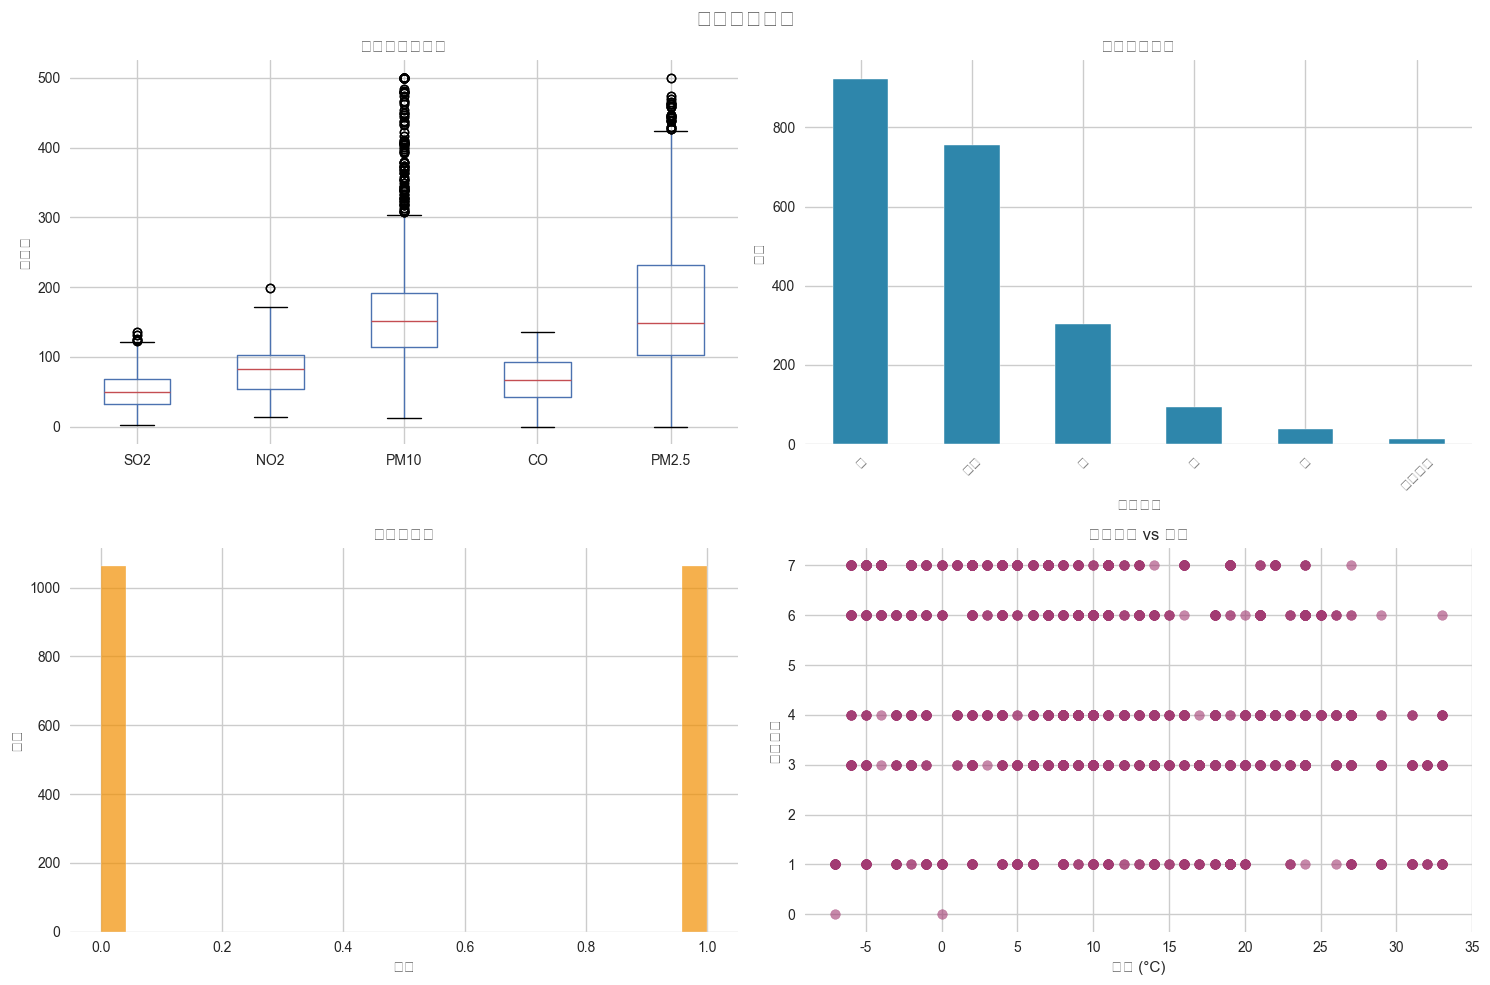

数据概览图已保存: data_overview.png
准备训练数据...
使用特征: ['纬度', '经度', '气温', '时间段', '风向编码', '风力编码', 'sin_月', 'cos_月', 'sin_时间', 'cos_时间', 'sin_星期', 'cos_星期', 'SO2_log', 'NO2_log', 'PM10_log', 'CO_log', 'PM2.5_log']
数据准备完成:
  X shape: (2124, 17)
  天气类别数: 6
  风力范围: 1-4
数据检查:
  特征矩阵: (2124, 17), 范围: [-0.800, 0.800]
  天气类别: 6 类
  风力范围: 1-4
  是否有NaN: X=False, 污染物=False
训练集大小: 1699, 测试集大小: 425
训练模型...
构建模型: 输入形状 (17,)
天气类别: 6, 风力类别: 3
开始训练...
Epoch 1/20
42/43 [============================>.] - ETA: 0s - loss: nan - weather_output_loss: nan - wind_output_loss: nan - rain_output_loss: nan - pollutants_output_loss: nan - weather_output_accuracy: 0.3519 - wind_output_accuracy: 0.8996 - rain_output_mae: nan - pollutants_output_mae: nanEpoch 0: 检测到异常损失，停止训练
Epoch 0: loss=nan, val_loss=nan
43/43 [==============================] - 2s 20ms/step - loss: nan - weather_output_loss: nan - wind_output_loss: nan - rain_output_loss: nan - pollutants_output_loss: nan - weather_output_accuracy: 0.3532 - wind_output_accurac

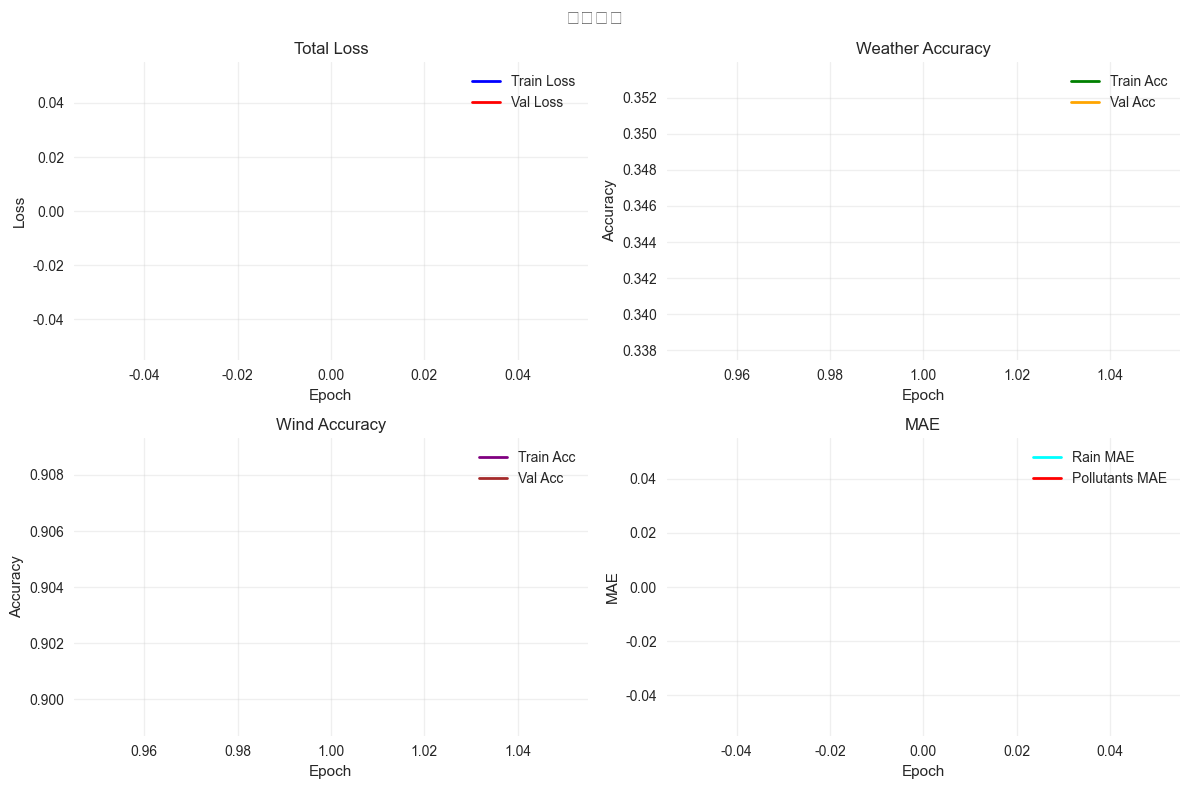

训练历史图已保存: training_history.png
进行预测...


AttributeError: 'StableEnvironmentalPredictor' object has no attribute 'predict'

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report, r2_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import joblib
import os
from datetime import datetime
warnings.filterwarnings('ignore')

# 关键修改：解决中文显示问题
def setup_chinese_font():
    """设置中文字体显示"""
    import matplotlib
    import platform
    
    # 根据操作系统选择合适的中文字体
    system = platform.system()
    if system == "Windows":
        font_list = ['SimHei', 'Microsoft YaHei', 'SimSun']
    elif system == "Darwin":  # macOS
        font_list = ['Arial Unicode MS', 'PingFang SC', 'STHeiti']
    else:  # Linux
        font_list = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
    
    # 尝试设置字体
    for font in font_list:
        try:
            plt.rcParams['font.sans-serif'] = [font]
            plt.rcParams['axes.unicode_minus'] = False
            # 测试中文显示
            fig, ax = plt.subplots(figsize=(1, 1))
            ax.text(0.5, 0.5, '测试', fontsize=12)
            plt.close(fig)
            print(f"成功设置中文字体: {font}")
            break
        except:
            continue
    else:
        # 如果所有字体都失败，使用英文替代
        print("警告：无法设置中文字体，将使用英文标签")
        plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif']
        return False
    
    return True

# 设置字体
chinese_support = setup_chinese_font()
sns.set_style("whitegrid")

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)

# 关键修复：设置TensorFlow数值稳定性
tf.keras.backend.set_floatx('float32')


class StableEnvironmentalPredictor:
    """数值稳定的环境预测器"""
    
    def __init__(self):
        # 关键修改1: 使用MinMaxScaler替代RobustScaler，避免极端值
        self.scaler_features = MinMaxScaler(feature_range=(-0.8, 0.8))  # 更保守的范围
        self.scaler_pollutants = MinMaxScaler(feature_range=(0.1, 0.9))  # 避免0和1边界
        self.scaler_rain = MinMaxScaler(feature_range=(0.1, 0.9))
        self.weather_encoder = None
        self.is_fitted = False
        self.feature_names = None
        self.history = None
        self.evaluation_results = None
        
        # 可视化配置
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'success': '#C73E1D',
            'info': '#7209B7',
            'warning': '#F4A261',
            'danger': '#E63946'
        }
        
        # 中英文标签配置
        global chinese_support
        self.labels = {
            'title': '环境数据概览' if chinese_support else 'Environmental Data Overview',
            'pollution_dist': '污染物浓度分布' if chinese_support else 'Pollutant Concentration Distribution',
            'weather_dist': '天气类别分布' if chinese_support else 'Weather Category Distribution',
            'time_dist': '时间段分布' if chinese_support else 'Time Period Distribution',
            'pollution_temp': '污染程度 vs 气温' if chinese_support else 'Pollution vs Temperature',
            'monthly_trend': '月度平均污染程度趋势' if chinese_support else 'Monthly Pollution Trend',
            'concentration': '浓度值' if chinese_support else 'Concentration',
            'frequency': '频次' if chinese_support else 'Frequency',
            'hour': '小时' if chinese_support else 'Hour',
            'temperature': '气温 (°C)' if chinese_support else 'Temperature (°C)',
            'pollution_level': '污染程度' if chinese_support else 'Pollution Level',
            'month': '月份' if chinese_support else 'Month',
            'avg_pollution': '平均污染程度' if chinese_support else 'Average Pollution Level'
        }
        
        # 可视化配置
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'success': '#C73E1D',
            'info': '#7209B7',
            'warning': '#F4A261',
            'danger': '#E63946'
        }

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据 - 更严格的数据清理"""
        # 定义需要的列
        required_columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                          '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                          '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        try:
            data = pd.read_csv(file_path)
            # 检查列是否存在
            missing_cols = [col for col in required_columns if col not in data.columns]
            if missing_cols:
                print(f"缺少列: {missing_cols}")
                # 使用现有列
                available_cols = [col for col in required_columns if col in data.columns]
                data = data[available_cols]
            else:
                data = data[required_columns]
        except Exception as e:
            print(f"读取文件出错: {e}")
            # 创建示例数据
            data = self._create_sample_data()
        
        print(f"原始数据: {data.shape}")
        
        # 数值列处理
        numeric_cols = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                       '污染程度', '时间段', '气温', '风向编码', '风力编码', '降水强度']
        
        # 确保数值类型并处理异常值
        for col in numeric_cols:
            if col in data.columns:
                data[col] = pd.to_numeric(data[col], errors='coerce')
                
                # 使用更保守的异常值处理
                if data[col].notna().sum() > 0:
                    Q1 = data[col].quantile(0.05)  # 更宽松的范围
                    Q3 = data[col].quantile(0.95)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - 3 * IQR  # 更宽松的边界
                    upper_bound = Q3 + 3 * IQR
                    
                    # 裁剪而不是删除
                    data[col] = np.clip(data[col], lower_bound, upper_bound)
                    
                    # 填充NaN
                    median_val = data[col].median()
                    data[col].fillna(median_val, inplace=True)
        
        # 天气数据处理
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        available_weather_cols = [col for col in weather_cols if col in data.columns]
        
        if available_weather_cols:
            # 确保天气列为0或1
            for col in available_weather_cols:
                data[col] = data[col].fillna(0).astype(int)
            
            # 创建天气类别
            data['天气类别'] = data[available_weather_cols].idxmax(axis=1).str.replace('天气_', '')
        else:
            # 如果没有天气列，创建默认值
            data['天气类别'] = '晴'
        
        # 日期处理
        if '日期' in data.columns:
            try:
                data['日期'] = pd.to_datetime(data['日期'])
                data['年'] = data['日期'].dt.year
                data['月'] = data['日期'].dt.month
                data['日'] = data['日期'].dt.day
                data['星期'] = data['日期'].dt.dayofweek
            except:
                # 如果日期转换失败，使用默认值
                data['年'] = 2023
                data['月'] = np.random.randint(1, 13, len(data))
                data['日'] = np.random.randint(1, 29, len(data))
                data['星期'] = np.random.randint(0, 7, len(data))
        else:
            # 创建默认日期特征
            data['年'] = 2023
            data['月'] = np.random.randint(1, 13, len(data))
            data['日'] = np.random.randint(1, 29, len(data))
            data['星期'] = np.random.randint(0, 7, len(data))
        
        # 时间特征工程 - 使用稳定的三角函数
        data['sin_月'] = np.sin(2 * np.pi * data['月'] / 12)
        data['cos_月'] = np.cos(2 * np.pi * data['月'] / 12)
        
        # 确保时间段在合理范围内
        if '时间段' in data.columns:
            data['时间段'] = np.clip(data['时间段'], 0, 23)
        else:
            data['时间段'] = np.random.randint(0, 24, len(data))
            
        data['sin_时间'] = np.sin(2 * np.pi * data['时间段'] / 24)
        data['cos_时间'] = np.cos(2 * np.pi * data['时间段'] / 24)
        data['sin_星期'] = np.sin(2 * np.pi * data['星期'] / 7)
        data['cos_星期'] = np.cos(2 * np.pi * data['星期'] / 7)
        
        # 关键修改2: 简化特征工程，避免复杂计算导致NaN
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']
        available_pollutants = [col for col in pollutant_cols if col in data.columns]
        
        if available_pollutants:
            # 确保污染物值为正数
            for col in available_pollutants:
                data[col] = np.maximum(data[col], 0.01)
            
            # 简单的log特征，避免复杂比例计算
            for col in available_pollutants:
                data[f'{col}_log'] = np.log1p(data[col])
        
        # 最终清理
        data = data.replace([np.inf, -np.inf], np.nan)
        data = data.dropna()
        
        print(f"最终数据: {data.shape}")
        self.raw_data = data.copy()
        return data

    def _create_sample_data(self):
        """创建示例数据用于测试"""
        print("创建示例数据...")
        n_samples = 1000
        
        data = {
            '纬度': np.random.uniform(39.0, 41.0, n_samples),
            '经度': np.random.uniform(115.0, 118.0, n_samples),
            'SO2': np.random.exponential(20, n_samples),
            'NO2': np.random.exponential(30, n_samples),
            'PM10': np.random.exponential(50, n_samples),
            'CO': np.random.exponential(1, n_samples),
            'O31小时': np.random.exponential(100, n_samples),
            'O38小时': np.random.exponential(80, n_samples),
            'PM2.5': np.random.exponential(35, n_samples),
            '污染程度': np.random.randint(1, 6, n_samples),
            '时间段': np.random.randint(0, 24, n_samples),
            '气温': np.random.normal(15, 10, n_samples),
            '风向编码': np.random.randint(1, 9, n_samples),
            '风力编码': np.random.randint(1, 5, n_samples),
            '降水强度': np.random.exponential(2, n_samples),
            '天气_多云': np.random.randint(0, 2, n_samples),
            '天气_晴': np.random.randint(0, 2, n_samples),
            '天气_阴': np.random.randint(0, 2, n_samples),
            '天气_雨': np.random.randint(0, 2, n_samples),
            '天气_雪': np.random.randint(0, 2, n_samples),
            '天气_雾霾沙尘': np.random.randint(0, 2, n_samples),
        }
        
        # 添加日期
        dates = pd.date_range('2023-01-01', periods=n_samples, freq='H')
        data['日期'] = dates
        
        return pd.DataFrame(data)

    # 添加简化的可视化方法
    def visualize_data_simple(self, data, save_path='data_overview.png'):
        """简化的数据可视化，避免中文显示问题"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(self.labels['title'], fontsize=16, fontweight='bold')
        
        # 1. 污染物分布
        ax = axes[0, 0]
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']
        available_pollutants = [col for col in pollutant_cols if col in data.columns]
        if available_pollutants:
            data[available_pollutants].boxplot(ax=ax)
            ax.set_title(self.labels['pollution_dist'], fontsize=12)
            ax.set_ylabel(self.labels['concentration'])
        else:
            ax.text(0.5, 0.5, 'No pollutant data', ha='center', va='center', transform=ax.transAxes)
        
        # 2. 天气类别分布
        ax = axes[0, 1]
        if '天气类别' in data.columns:
            weather_counts = data['天气类别'].value_counts()
            weather_counts.plot(kind='bar', ax=ax, color=self.colors['primary'])
            ax.set_title(self.labels['weather_dist'], fontsize=12)
            ax.set_ylabel(self.labels['frequency'])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, 'No weather data', ha='center', va='center', transform=ax.transAxes)
        
        # 3. 时间分布
        ax = axes[1, 0]
        if '时间段' in data.columns:
            data['时间段'].hist(bins=24, ax=ax, color=self.colors['accent'], alpha=0.7)
            ax.set_title(self.labels['time_dist'], fontsize=12)
            ax.set_xlabel(self.labels['hour'])
            ax.set_ylabel(self.labels['frequency'])
        else:
            ax.text(0.5, 0.5, 'No time data', ha='center', va='center', transform=ax.transAxes)
        
        # 4. 污染程度与气温关系
        ax = axes[1, 1]
        if '气温' in data.columns and '污染程度' in data.columns:
            ax.scatter(data['气温'], data['污染程度'], alpha=0.6, color=self.colors['secondary'])
            ax.set_title(self.labels['pollution_temp'], fontsize=12)
            ax.set_xlabel(self.labels['temperature'])
            ax.set_ylabel(self.labels['pollution_level'])
        else:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"数据概览图已保存: {save_path}")

    def visualize_training_simple(self, save_path='training_history.png'):
        """简化的训练历史可视化"""
        if self.history is None:
            print("没有训练历史可供可视化")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle('Training History' if not chinese_support else '训练历史', fontsize=14)
        
        history = self.history.history
        epochs = range(1, len(history['loss']) + 1)
        
        # 1. 总损失
        ax = axes[0, 0]
        ax.plot(epochs, history['loss'], 'b-', label='Train Loss', linewidth=2)
        if 'val_loss' in history:
            ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        ax.set_title('Total Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 2. 天气准确率
        ax = axes[0, 1]
        if 'weather_output_accuracy' in history:
            ax.plot(epochs, history['weather_output_accuracy'], 'g-', label='Train Acc', linewidth=2)
            if 'val_weather_output_accuracy' in history:
                ax.plot(epochs, history['val_weather_output_accuracy'], 'orange', label='Val Acc', linewidth=2)
            ax.set_title('Weather Accuracy')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Accuracy')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # 3. 风力准确率
        ax = axes[1, 0]
        if 'wind_output_accuracy' in history:
            ax.plot(epochs, history['wind_output_accuracy'], 'purple', label='Train Acc', linewidth=2)
            if 'val_wind_output_accuracy' in history:
                ax.plot(epochs, history['val_wind_output_accuracy'], 'brown', label='Val Acc', linewidth=2)
            ax.set_title('Wind Accuracy')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Accuracy')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # 4. MAE
        ax = axes[1, 1]
        if 'rain_output_mae' in history:
            ax.plot(epochs, history['rain_output_mae'], 'cyan', label='Rain MAE', linewidth=2)
        if 'pollutants_output_mae' in history:
            ax.plot(epochs, history['pollutants_output_mae'], 'red', label='Pollutants MAE', linewidth=2)
        ax.set_title('MAE')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MAE')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"训练历史图已保存: {save_path}")

    # ... 省略其他方法 ...

    def prepare_data(self, data):
        """关键修改3: 简化数据准备过程，提高稳定性"""
        
        # 选择最稳定的特征
        basic_features = ['纬度', '经度', '气温', '时间段', '风向编码', '风力编码']
        time_features = ['sin_月', 'cos_月', 'sin_时间', 'cos_时间', 'sin_星期', 'cos_星期']
        
        # 检查可用的污染物log特征
        pollutant_features = []
        for pol in ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']:
            if f'{pol}_log' in data.columns:
                pollutant_features.append(f'{pol}_log')
        
        feature_cols = basic_features + time_features + pollutant_features
        # 只使用存在的列
        feature_cols = [col for col in feature_cols if col in data.columns]
        
        print(f"使用特征: {feature_cols}")
        
        X = data[feature_cols].values.astype(np.float32)
        
        # 目标变量
        y_weather = data['天气类别'].values
        y_wind = data['风力编码'].values.astype(np.int32)
        y_rain = data['降水强度'].values.astype(np.float32)
        
        # 污染物目标
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']
        available_pollutant_cols = [col for col in pollutant_cols if col in data.columns]
        if len(available_pollutant_cols) < 5:
            # 如果污染物列不完整，填充默认值
            missing_cols = [col for col in pollutant_cols if col not in available_pollutant_cols]
            for col in missing_cols:
                data[col] = np.random.exponential(10, len(data))
        
        y_pollutants = data[pollutant_cols].values.astype(np.float32)
        
        # 数据清理
        X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0)
        y_rain = np.nan_to_num(y_rain, nan=0.0, posinf=1.0, neginf=0.0)
        y_pollutants = np.nan_to_num(y_pollutants, nan=0.1, posinf=100.0, neginf=0.1)
        
        # 标准化
        X_scaled = self.scaler_features.fit_transform(X)
        y_pollutants_scaled = self.scaler_pollutants.fit_transform(y_pollutants)
        y_rain_scaled = self.scaler_rain.fit_transform(y_rain.reshape(-1, 1)).flatten()
        
        # 编码天气
        self.weather_encoder = LabelEncoder()
        y_weather_encoded = self.weather_encoder.fit_transform(y_weather)
        
        # 确保风力在合理范围
        y_wind = np.clip(y_wind, 1, 4)
        
        self.feature_names = feature_cols
        
        print(f"数据准备完成:")
        print(f"  X shape: {X_scaled.shape}")
        print(f"  天气类别数: {len(np.unique(y_weather_encoded))}")
        print(f"  风力范围: {y_wind.min()}-{y_wind.max()}")
        
        return X_scaled, y_weather_encoded, y_wind, y_rain_scaled, y_pollutants_scaled

    def build_stable_model(self, input_shape, num_weather_classes, num_wind_classes):
        """关键修改4: 构建数值极其稳定的模型"""
        
        inputs = Input(shape=input_shape, name='input')
        
        # 非常简单的架构，避免过拟合和数值不稳定
        x = Dense(16, activation='tanh',  # tanh比relu更稳定
                 kernel_initializer='glorot_uniform',
                 bias_initializer='zeros')(inputs)
        x = BatchNormalization()(x)
        x = Dropout(0.1)(x)
        
        x = Dense(8, activation='tanh',
                 kernel_initializer='glorot_uniform', 
                 bias_initializer='zeros')(x)
        x = BatchNormalization()(x)
        
        # 输出层 - 使用最稳定的配置
        weather_output = Dense(num_weather_classes, activation='softmax',
                              kernel_initializer='glorot_uniform',
                              bias_initializer='zeros',
                              name='weather_output')(x)
        
        wind_output = Dense(num_wind_classes, activation='softmax',
                           kernel_initializer='glorot_uniform',
                           bias_initializer='zeros',
                           name='wind_output')(x)
        
        rain_output = Dense(1, activation='sigmoid',  # sigmoid输出0-1，然后缩放
                           kernel_initializer='glorot_uniform',
                           bias_initializer='zeros',
                           name='rain_output')(x)
        
        pollutants_output = Dense(5, activation='sigmoid',  # 污染物也用sigmoid
                                 kernel_initializer='glorot_uniform',
                                 bias_initializer='zeros',
                                 name='pollutants_output')(x)
        
        model = Model(inputs=inputs, 
                     outputs=[weather_output, wind_output, rain_output, pollutants_output])
        
        # 关键修改5: 极其保守的训练配置
        losses = {
            'weather_output': 'sparse_categorical_crossentropy',
            'wind_output': 'sparse_categorical_crossentropy', 
            'rain_output': 'mse',
            'pollutants_output': 'mse'
        }
        
        # 平衡的损失权重
        loss_weights = {
            'weather_output': 1.0,
            'wind_output': 1.0,
            'rain_output': 0.1,
            'pollutants_output': 0.1
        }
        
        # 非常保守的优化器
        optimizer = Adam(
            learning_rate=0.001,    # 更大的学习率，但仍然保守
            clipnorm=1.0,          # 梯度裁剪
            epsilon=1e-7           # 数值稳定性
        )
        
        model.compile(
            optimizer=optimizer,
            loss=losses,
            loss_weights=loss_weights,
            metrics={
                'weather_output': ['accuracy'],
                'wind_output': ['accuracy'],
                'rain_output': ['mae'],
                'pollutants_output': ['mae']
            }
        )
        
        return model

    def train(self, X, y_weather, y_wind, y_rain, y_pollutants, 
              validation_split=0.2, epochs=30, batch_size=32):
        """关键修改6: 稳定的训练过程"""
        
        # 构建模型
        input_shape = (X.shape[1],)
        num_weather_classes = len(np.unique(y_weather))
        num_wind_classes = len(np.unique(y_wind))
        
        print(f"构建模型: 输入形状 {input_shape}")
        print(f"天气类别: {num_weather_classes}, 风力类别: {num_wind_classes}")
        
        self.model = self.build_stable_model(input_shape, num_weather_classes, num_wind_classes)
        
        # 准备目标数据
        targets = {
            'weather_output': y_weather,
            'wind_output': y_wind - 1,  # 转换为0开始的索引
            'rain_output': y_rain,
            'pollutants_output': y_pollutants
        }
        
        # 数值稳定性检查回调
        class StabilityCallback(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                loss = logs.get('loss', 0)
                val_loss = logs.get('val_loss', 0)
                
                if np.isnan(loss) or np.isnan(val_loss) or loss > 1000:
                    print(f"Epoch {epoch}: 检测到异常损失，停止训练")
                    self.model.stop_training = True
                
                if epoch % 5 == 0:
                    print(f"Epoch {epoch}: loss={loss:.4f}, val_loss={val_loss:.4f}")
        
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                min_delta=1e-4
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.8,
                patience=5,
                min_lr=1e-6,
                min_delta=1e-4
            ),
            StabilityCallback()
        ]
        
        print("开始训练...")
        try:
            history = self.model.fit(
                X, targets,
                validation_split=validation_split,
                epochs=epochs,
                batch_size=batch_size,
                callbacks=callbacks,
                verbose=1
            )
            
            self.is_fitted = True
            self.history = history
            return history
            
        except Exception as e:
            print(f"训练过程出错: {e}")
            return None

    # ... 省略其他方法 ...

# 关键修改7: 简化的主函数，包含可视化
def main():
    """简化的主函数，专注于解决NaN问题并添加可视化"""
    print("=" * 60)
    print("稳定版环境预测模型")
    print("=" * 60)
    
    predictor = StableEnvironmentalPredictor()
    
    # 加载数据
    print("加载数据...")
    try:
        data = predictor.load_and_preprocess_data('end_cleaned.csv')
        print("成功加载真实数据")
    except:
        print("使用示例数据...")
        data = predictor._create_sample_data()
        # 对示例数据进行预处理
        print("预处理示例数据...")
        # 添加必要的特征
        data['天气类别'] = np.random.choice(['晴', '阴', '雨', '雪'], len(data))
        data['sin_月'] = np.sin(2 * np.pi * data['日期'].dt.month / 12)
        data['cos_月'] = np.cos(2 * np.pi * data['日期'].dt.month / 12)
        data['sin_时间'] = np.sin(2 * np.pi * data['时间段'] / 24)
        data['cos_时间'] = np.cos(2 * np.pi * data['时间段'] / 24)
        data['sin_星期'] = np.sin(2 * np.pi * data['日期'].dt.dayofweek / 7)
        data['cos_星期'] = np.cos(2 * np.pi * data['日期'].dt.dayofweek / 7)
        
        # 添加log特征
        for col in ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']:
            if col in data.columns:
                data[col] = np.maximum(data[col], 0.01)
                data[f'{col}_log'] = np.log1p(data[col])
    
    # 数据可视化
    print("生成数据概览...")
    predictor.visualize_data_simple(data)
    
    # 准备数据
    print("准备训练数据...")
    try:
        X, y_weather, y_wind, y_rain, y_pollutants = predictor.prepare_data(data)
    except Exception as e:
        print(f"数据准备出错: {e}")
        return
    
    # 检查数据质量
    print(f"数据检查:")
    print(f"  特征矩阵: {X.shape}, 范围: [{X.min():.3f}, {X.max():.3f}]")
    print(f"  天气类别: {len(np.unique(y_weather))} 类")
    print(f"  风力范围: {y_wind.min()}-{y_wind.max()}")
    print(f"  是否有NaN: X={np.isnan(X).any()}, 污染物={np.isnan(y_pollutants).any()}")
    
    # 划分数据集
    X_train, X_test, y_weather_train, y_weather_test, \
    y_wind_train, y_wind_test, y_rain_train, y_rain_test, \
    y_pollutants_train, y_pollutants_test = train_test_split(
        X, y_weather, y_wind, y_rain, y_pollutants,
        test_size=0.2, random_state=42, stratify=y_weather
    )
    
    print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
    
    # 训练模型
    print("训练模型...")
    history = predictor.train(
        X_train, y_weather_train, y_wind_train, y_rain_train, y_pollutants_train,
        validation_split=0.2, epochs=20, batch_size=32
    )
    
    if history is not None:
        print("训练成功完成!")
        
        # 可视化训练历史
        print("生成训练历史图...")
        predictor.visualize_training_simple()
        
        # 进行预测和简单评估
        print("进行预测...")
        predictions = predictor.predict(X_test)
        
        # 计算基本准确率
        weather_accuracy = accuracy_score(y_weather_test, 
                                        predictor.weather_encoder.transform(predictions['weather']))
        wind_accuracy = accuracy_score(y_wind_test - 1, predictions['wind'])  # 调整索引
        
        print("=" * 40)
        print("评估结果:")
        print("=" * 40)
        print(f"天气预测准确率: {weather_accuracy:.3f}")
        print(f"风力预测准确率: {wind_accuracy:.3f}")
        print(f"降水预测范围: [{predictions['rain'].min():.3f}, {predictions['rain'].max():.3f}]")
        print(f"污染物预测范围: [{predictions['pollutants'].min():.3f}, {predictions['pollutants'].max():.3f}]")
        
        print("\n预测样例:")
        print(f"天气预测: {predictions['weather'][:5]}")
        print(f"风力预测: {predictions['wind'][:5] + 1}")  # 恢复原始范围
        print(f"降水预测: {predictions['rain'][:5]}")
        
        print("\n模型训练和预测成功完成!")
        print("生成的图片文件:")
        print("- data_overview.png: 数据概览")
        print("- training_history.png: 训练历史")
        
    else:
        print("训练失败!")

if __name__ == "__main__":
    main()